# AI 221 Assignment 6: Dimensionality Reduction (PCA and LDA)

<b>Description:</b> This notebook demonstrates classification on students' dropout and academic success, particularly demonstrating dimensionality reduction techniques (PCA and LDA). Dataset used is the Students' Dropout and Academic Success Dataset that can be found on https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

## Data fetching and preliminary data checks

In [2]:
# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# fetching the car evaluation dataset 
student = fetch_ucirepo(id=697) # alternatively: fetch_ucirepo(name='Predict Students' Dropout and Academic Success ')
student_df = student.data.original

# checking the data
display(student_df)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [3]:
# checking metadata
print("Metadata:")
print(student.metadata) 
print()

# checking variable information
print("Variable information:")
print(student.variables) 

Metadata:
{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 

In [4]:
# checking info of the DataFrame
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

There are 36 features, all numerical. The target is either "Dropout" or "Graduate".

In [5]:
# checking descriptive statistics for each column
student_df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
# checking missing values
print(f"Missing values in the DataFrame: \n{student_df.isnull().sum()}\n")

Missing values in the DataFrame: 
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder            

It is evident that there are no missing values (as also explicitly mentioned in the dataset website).

## EDA

In [7]:
# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# for dataset manipulation and computation
import pandas as pd
import numpy as np

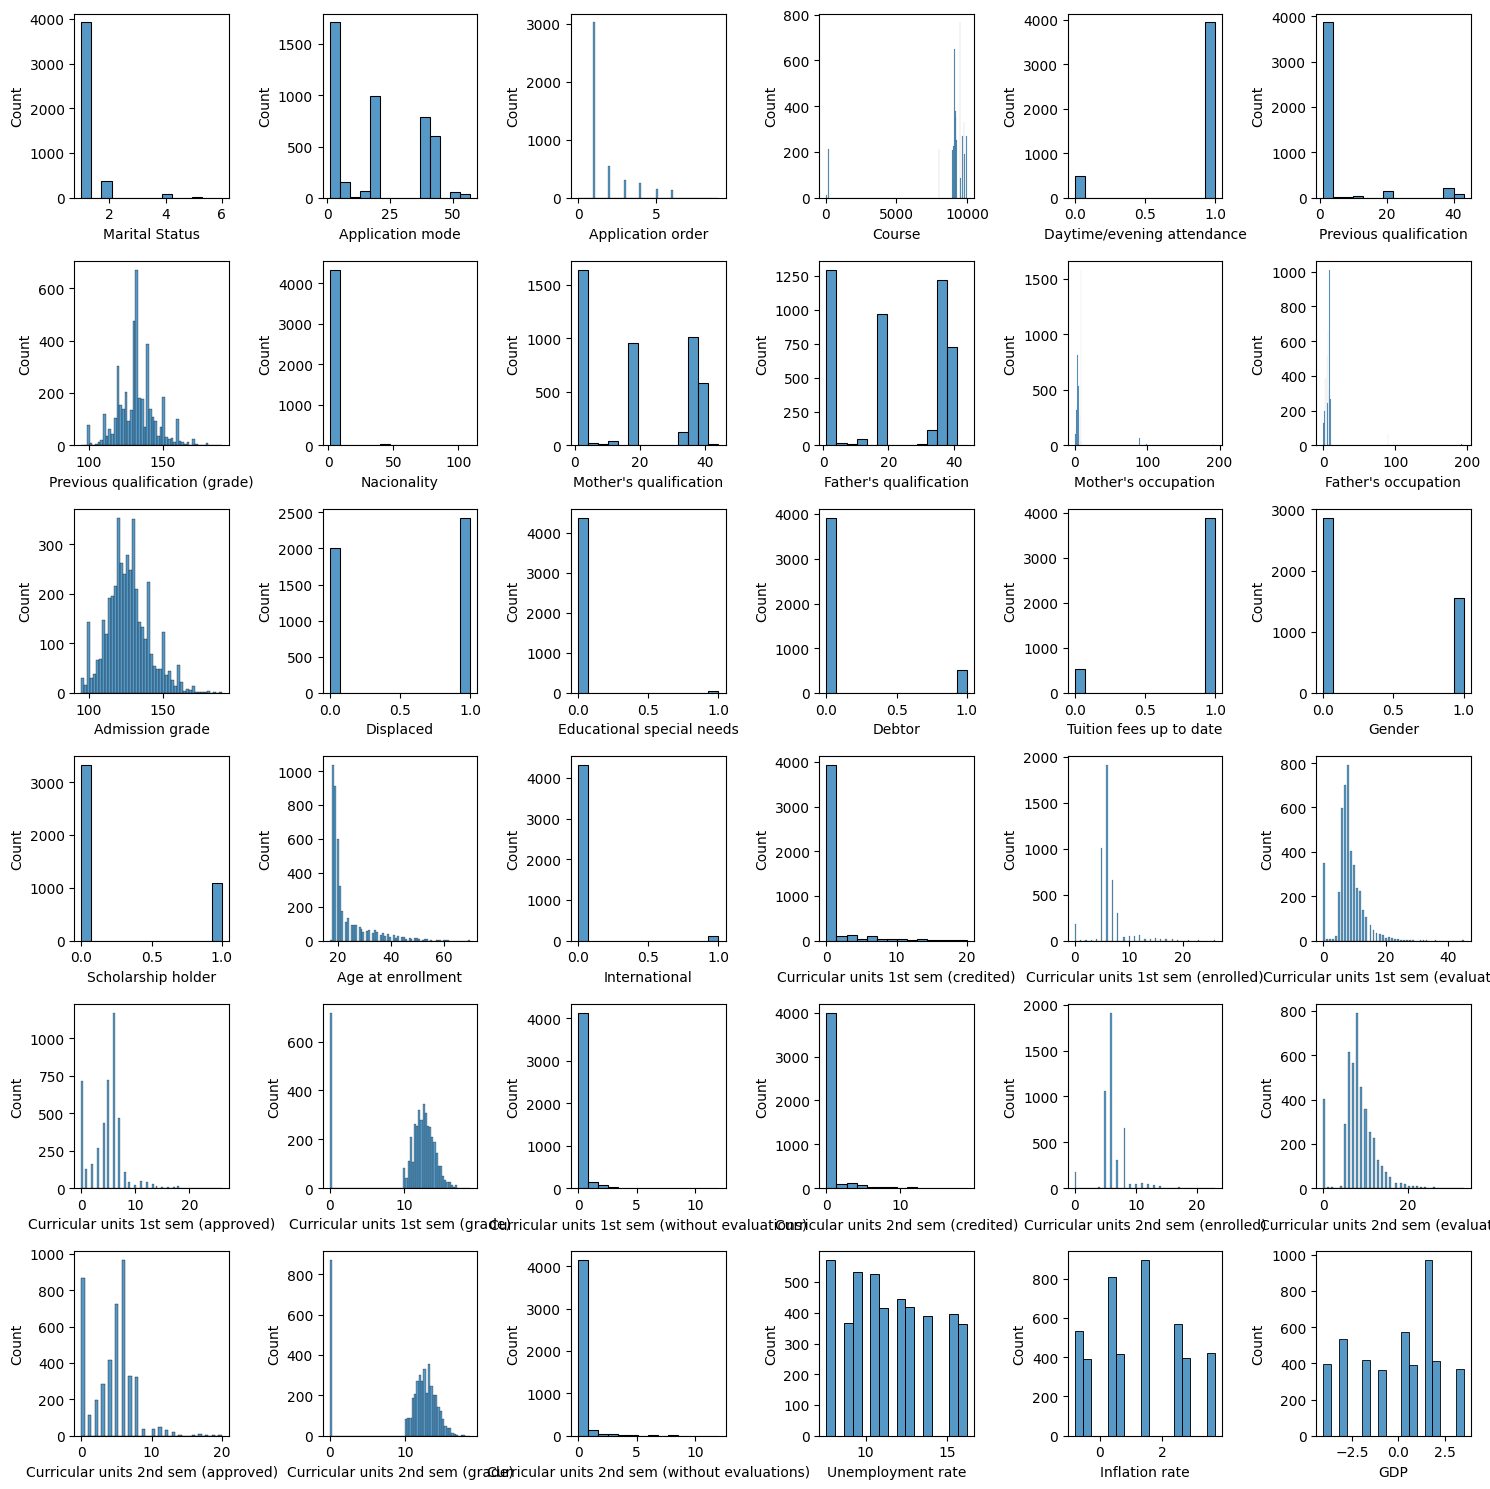

In [8]:
# checking the distribution of all features

fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(15, 15))

axes = axes.flatten()

# looping through all columns, except Target
for i, col in enumerate(student_df.columns[:-1]):
    sns.histplot(student_df[col], ax=axes[i])

plt.tight_layout()
plt.show()

In [9]:
# checking unique values of the target
print(f"Unique values of the target: {student_df["Target"].unique()}")
print(f"Count for each 'Target' unique values: {student_df["Target"].value_counts()}")

Unique values of the target: ['Dropout' 'Graduate' 'Enrolled']
Count for each 'Target' unique values: Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


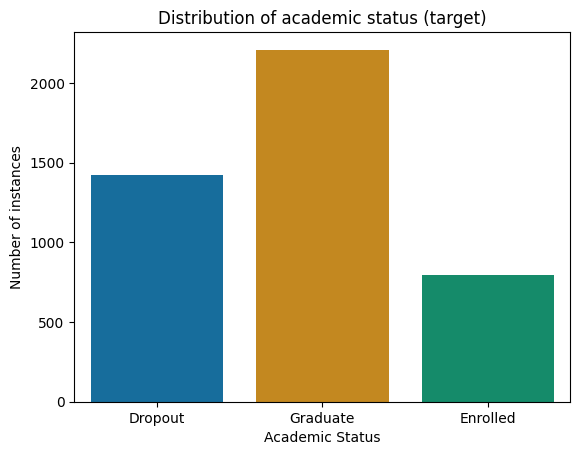

In [10]:
# plotting the distribution of the target
sns.countplot(data=student_df, x="Target", hue="Target", palette="colorblind")
plt.xlabel("Academic Status")
plt.ylabel("Number of instances")
plt.title("Distribution of academic status (target)")
plt.show()

There are much more graduates than dropout or enrolled in the dataset.

In [11]:
# separating integer (categorical) and continuous columns

continuous_cols = student_df.select_dtypes(include=['float64']).columns.tolist()

print("Continuous Columns: ")
for col in continuous_cols:
    print(f"- {col}")
print(f"Count: {len(continuous_cols)} columns")

print()

categorical_cols = student_df.select_dtypes(include=['int64']).columns.tolist()

print("Categorical Columns:")
for col in categorical_cols:
    print(f"- {col}")
print(f"Count: {len(categorical_cols)} columns")

Continuous Columns: 
- Previous qualification (grade)
- Admission grade
- Curricular units 1st sem (grade)
- Curricular units 2nd sem (grade)
- Unemployment rate
- Inflation rate
- GDP
Count: 7 columns

Categorical Columns:
- Marital Status
- Application mode
- Application order
- Course
- Daytime/evening attendance
- Previous qualification
- Nacionality
- Mother's qualification
- Father's qualification
- Mother's occupation
- Father's occupation
- Displaced
- Educational special needs
- Debtor
- Tuition fees up to date
- Gender
- Scholarship holder
- Age at enrollment
- International
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (without evaluations)


In [12]:
student_continuous_df = pd.concat([student_df[continuous_cols], student_df["Target"]], axis=1)

display(student_continuous_df)

,Previous qualification (grade),Admission grade,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target
0,122.0,127.3,0.000000,0.000000,10.8,1.4,1.74,Dropout
1,160.0,142.5,14.000000,13.666667,13.9,-0.3,0.79,Graduate
2,122.0,124.8,0.000000,0.000000,10.8,1.4,1.74,Dropout
3,122.0,119.6,13.428571,12.400000,9.4,-0.8,-3.12,Graduate
4,100.0,141.5,12.333333,13.000000,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...
4419,125.0,122.2,13.600000,12.666667,15.5,2.8,-4.06,Graduate
4420,120.0,119.0,12.000000,11.000000,11.1,0.6,2.02,Dropout
4421,154.0,149.5,14.912500,13.500000,13.9,-0.3,0.79,Dropout
4422,180.0,153.8,13.800000,12.000000,9.4,-0.8,-3.12,Graduate


In [13]:
student_categorical_df = pd.concat([student_df[categorical_cols], student_df["Target"]], axis=1)

display(student_categorical_df)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (without evaluations),Target
0,1,17,5,171,1,1,1,19,12,5,...,0,0,0,0,0,0,0,0,0,Dropout
1,1,15,1,9254,1,1,1,1,3,3,...,6,6,6,0,0,6,6,6,0,Graduate
2,1,1,5,9070,1,1,1,37,37,9,...,6,0,0,0,0,6,0,0,0,Dropout
3,1,17,2,9773,1,1,1,38,37,5,...,6,8,6,0,0,6,10,5,0,Graduate
4,2,39,1,8014,0,1,1,37,38,9,...,6,9,5,0,0,6,6,6,0,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,1,1,1,5,...,6,7,5,0,0,6,8,5,0,Graduate
4420,1,1,2,9773,1,1,105,1,1,9,...,6,6,6,0,0,6,6,2,0,Dropout
4421,1,1,1,9500,1,1,1,37,37,9,...,7,8,7,0,0,8,9,1,0,Dropout
4422,1,1,1,9147,1,1,1,37,37,7,...,5,5,5,0,0,5,6,5,0,Graduate


In [14]:
# checking the unique values of each categorical column, and checking the count of each unique value of the column
# looping through all columns 
for col in list(student_categorical_df.columns):
    print(f"'{col}' unique values: {student_categorical_df[col].unique()}")
    print(f"Count for each '{col}' unique values: {student_categorical_df[col].value_counts()}")
    print()

'Marital Status' unique values: [1 2 4 3 5 6]
Count for each 'Marital Status' unique values: Marital Status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64

'Application mode' unique values: [17 15  1 39 18 53 44 51 43  7 42 16  5  2 10 57 26 27]
Count for each 'Application mode' unique values: Application mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64

'Application order' unique values: [5 1 2 4 3 6 9 0]
Count for each 'Application order' unique values: Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64

'Course' unique values: [ 171 9254 9070 9773 8014 9991 9500 9238 9670 9853 9085 9130 9556 9147
 9003   33 9119]
Count for each 'Course' unique values: Course
9500    766
9147    380
9238    355
90

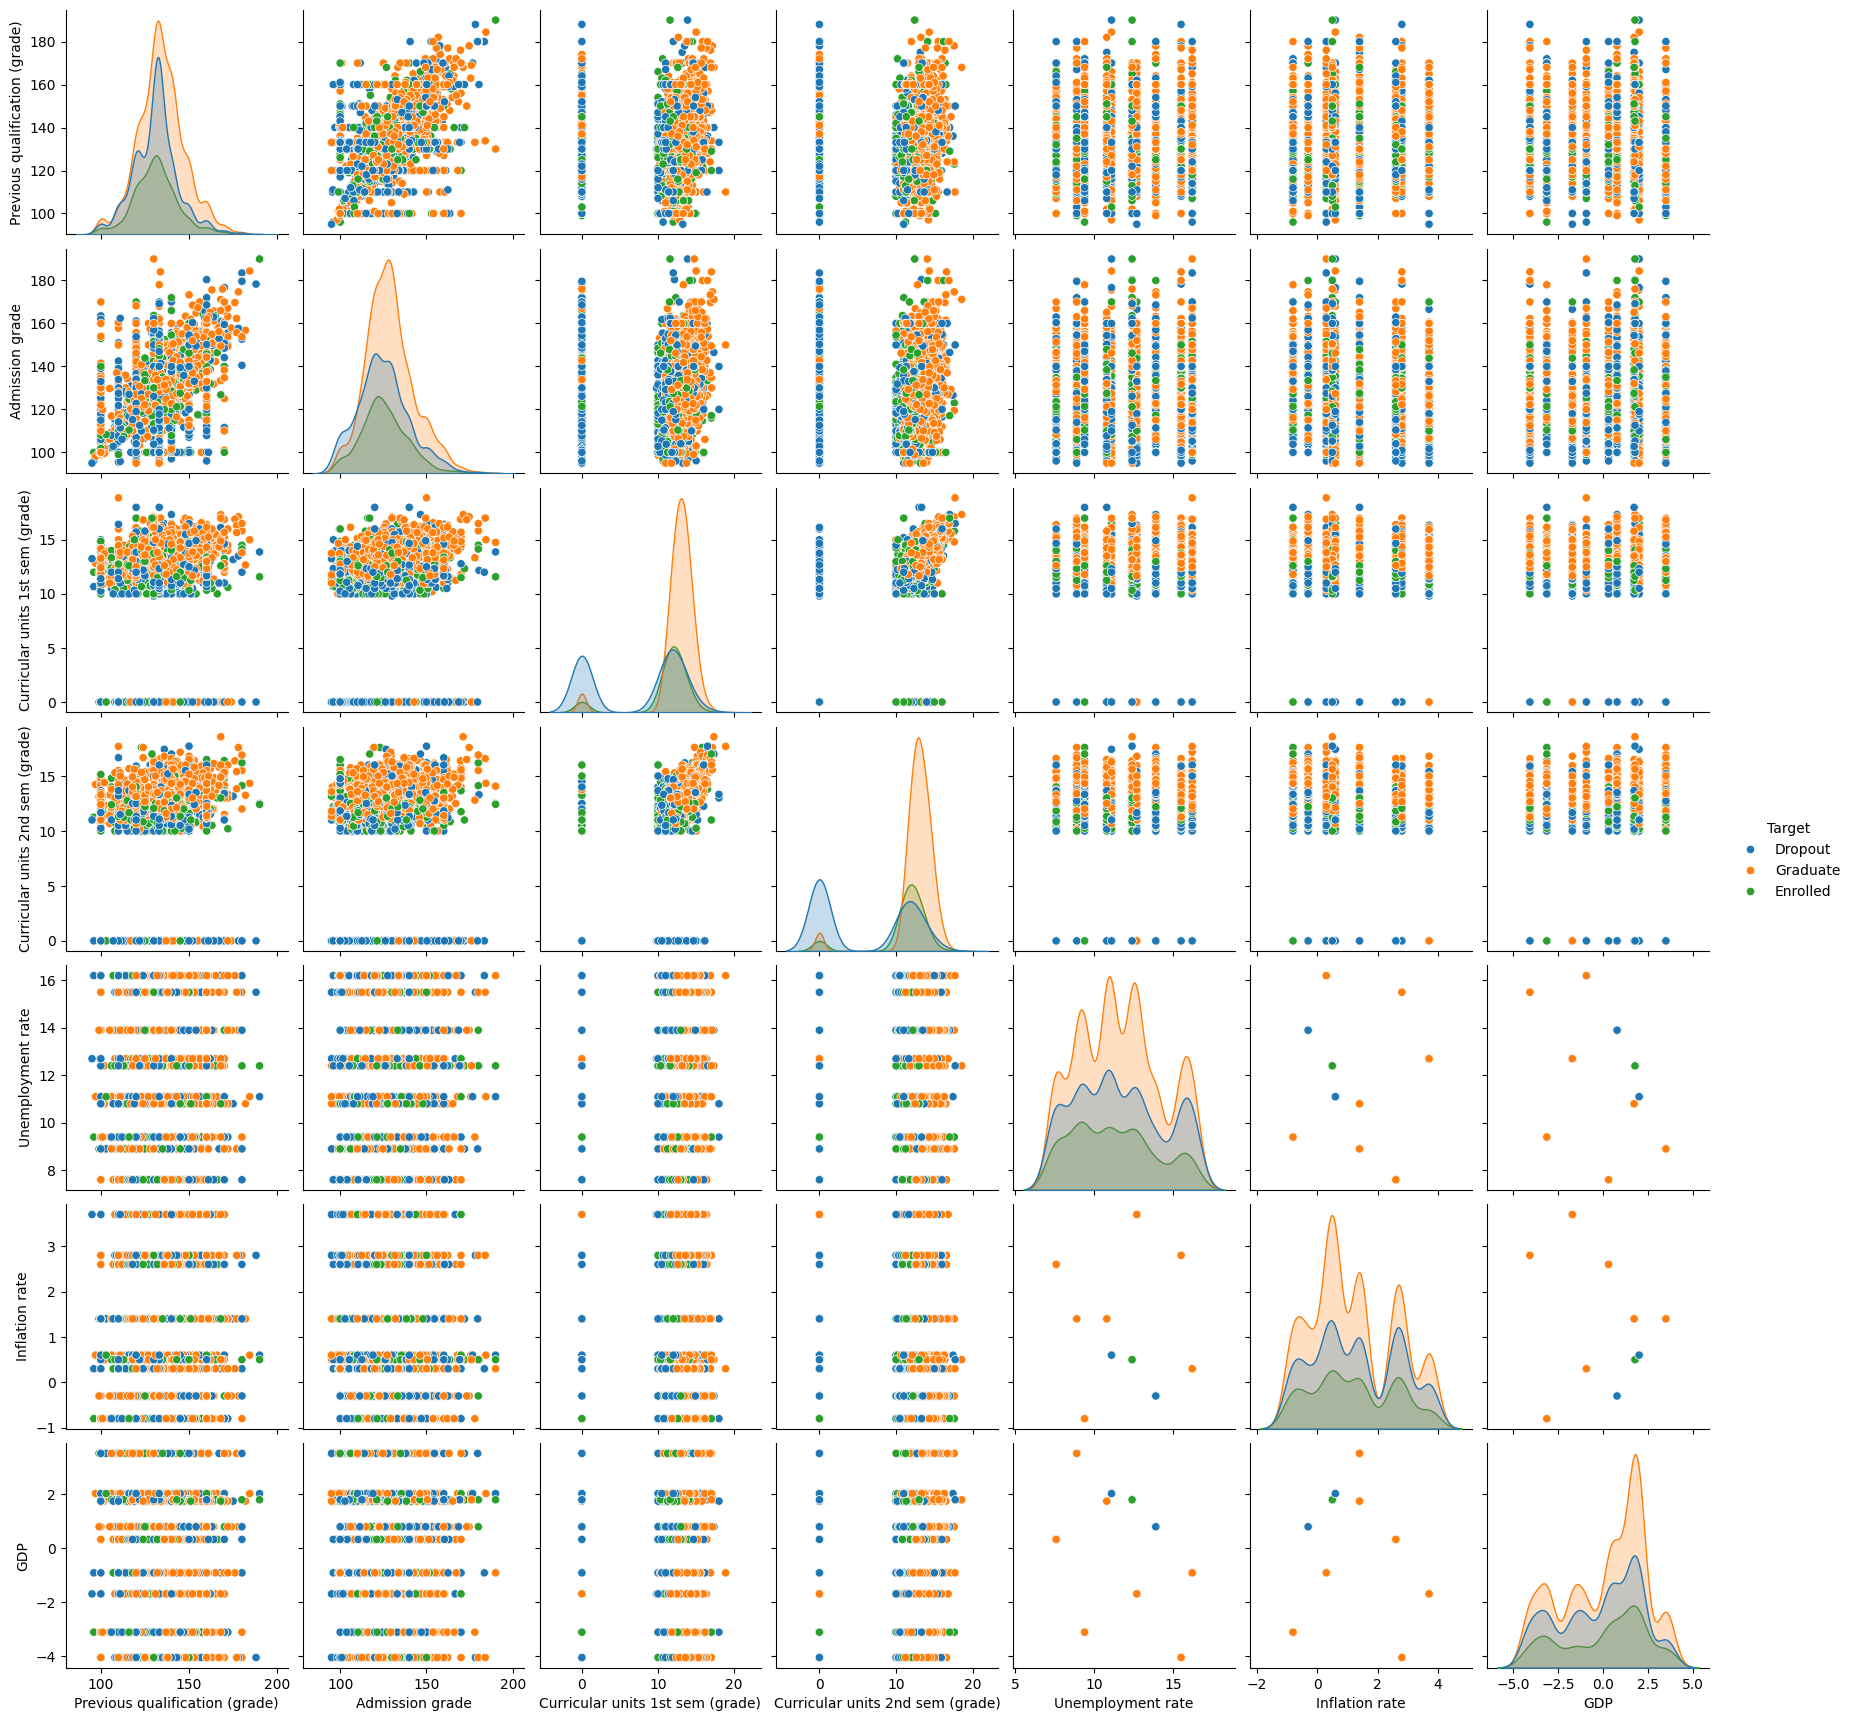

In [15]:
# creating a pairplot for all continuous features
sns.pairplot(data=student_continuous_df, hue="Target")
plt.show()

Based on the plot, there's no clear separation among the three student statuses across the continuous features.

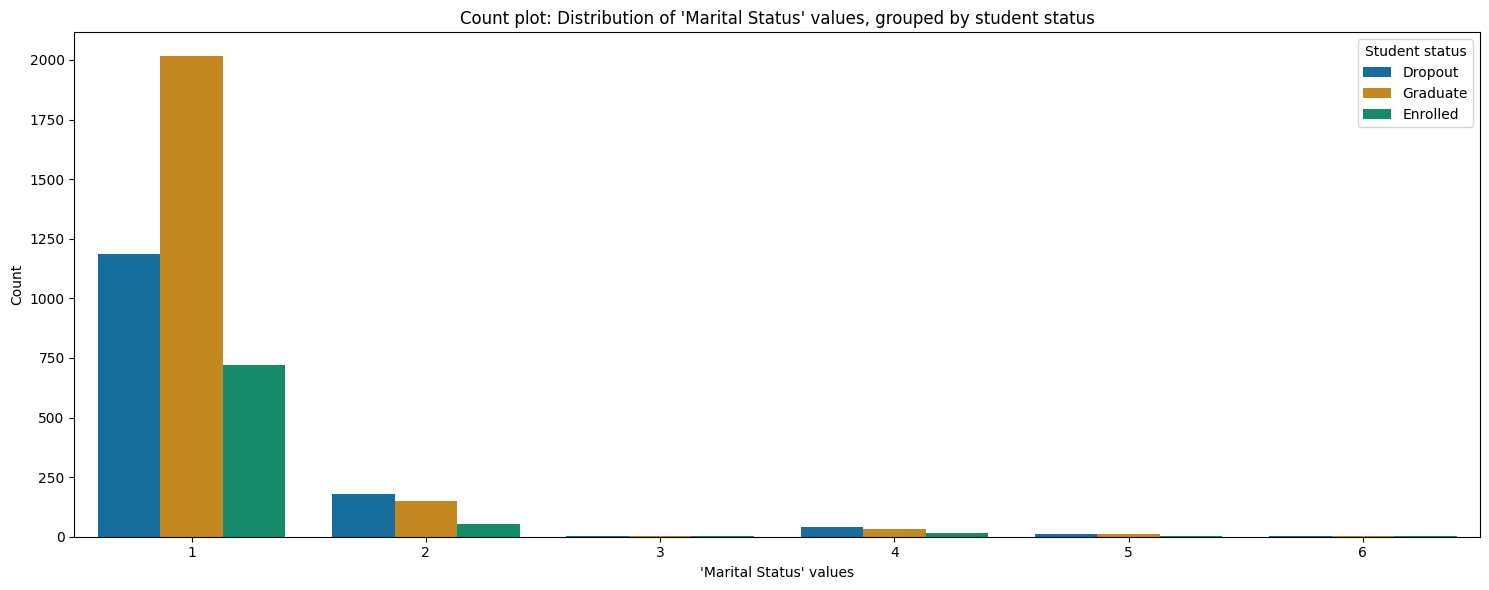

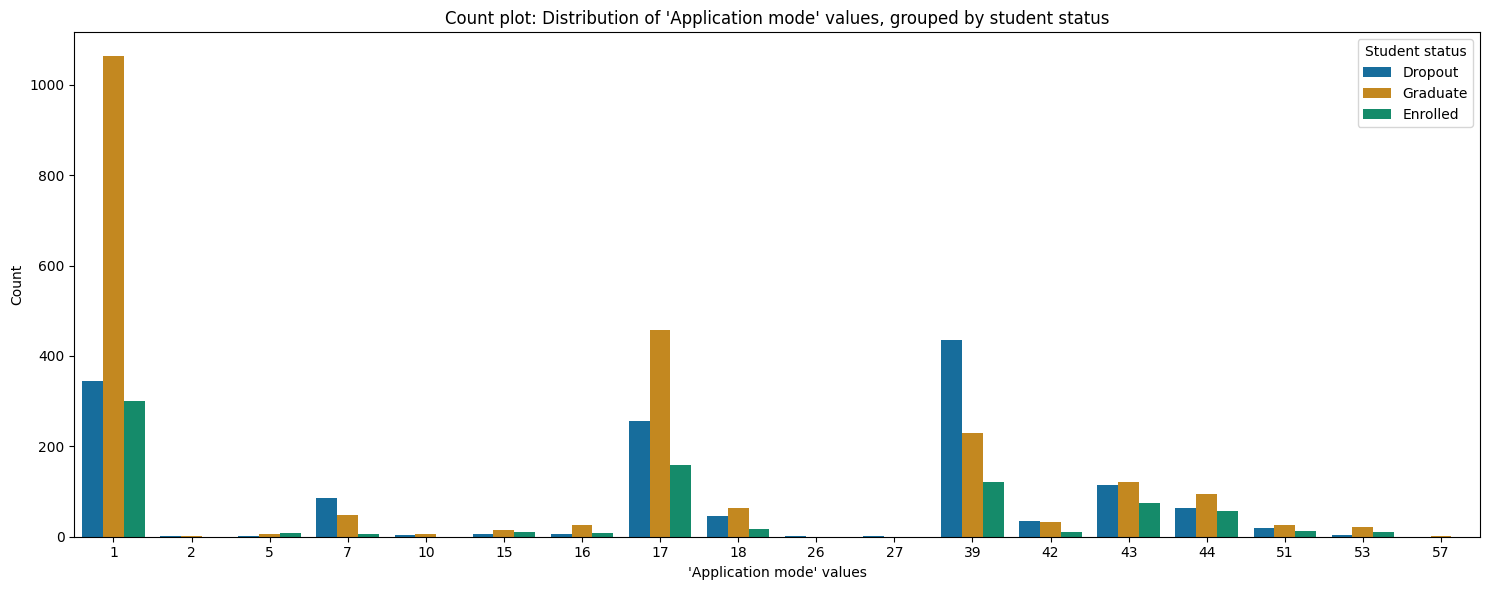

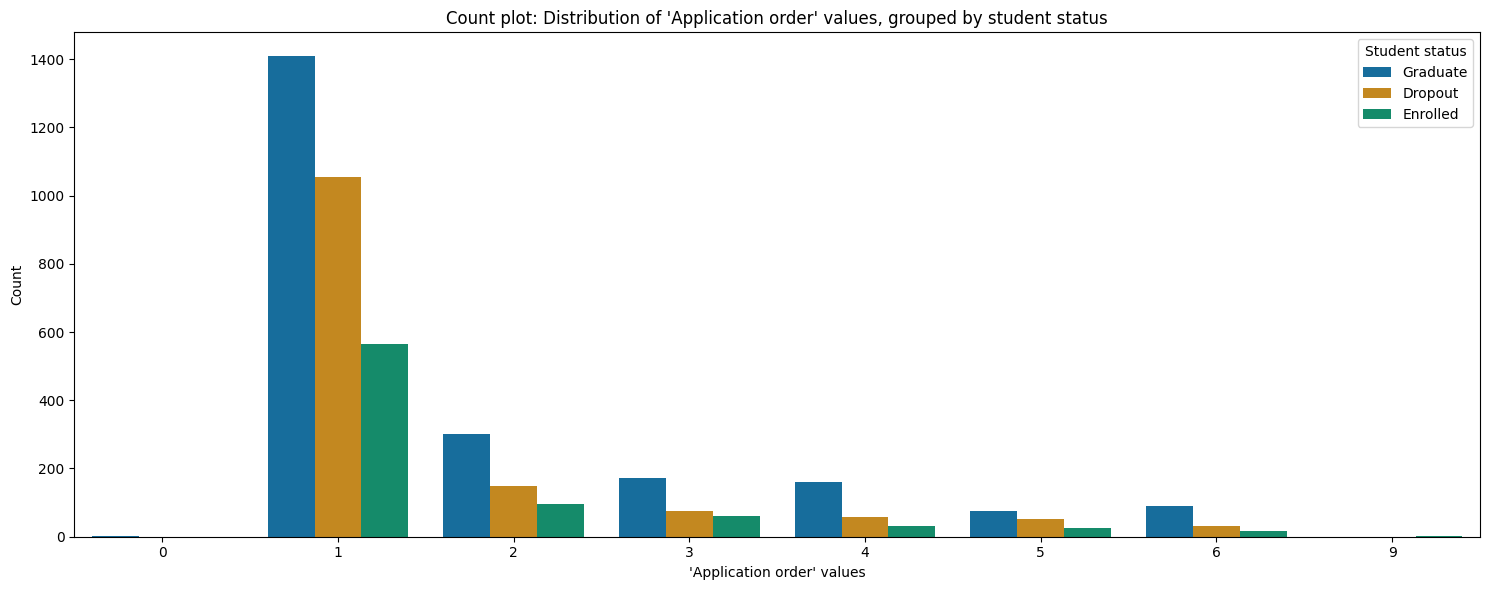

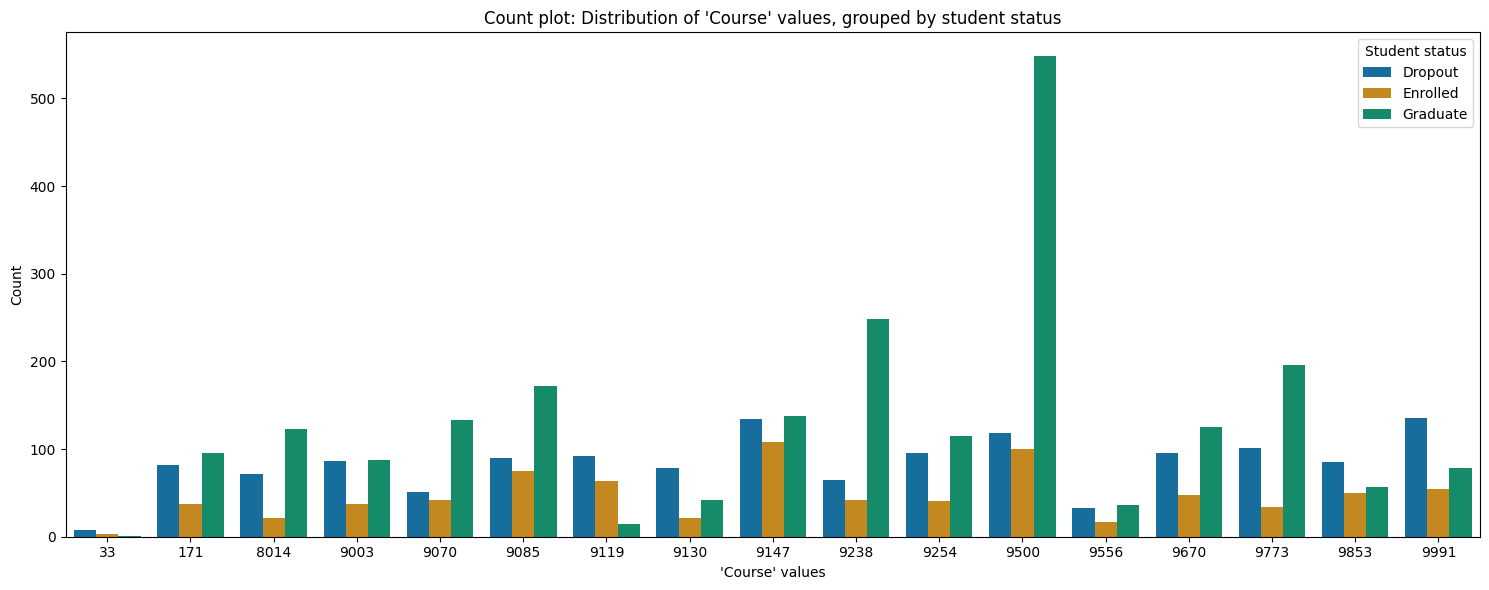

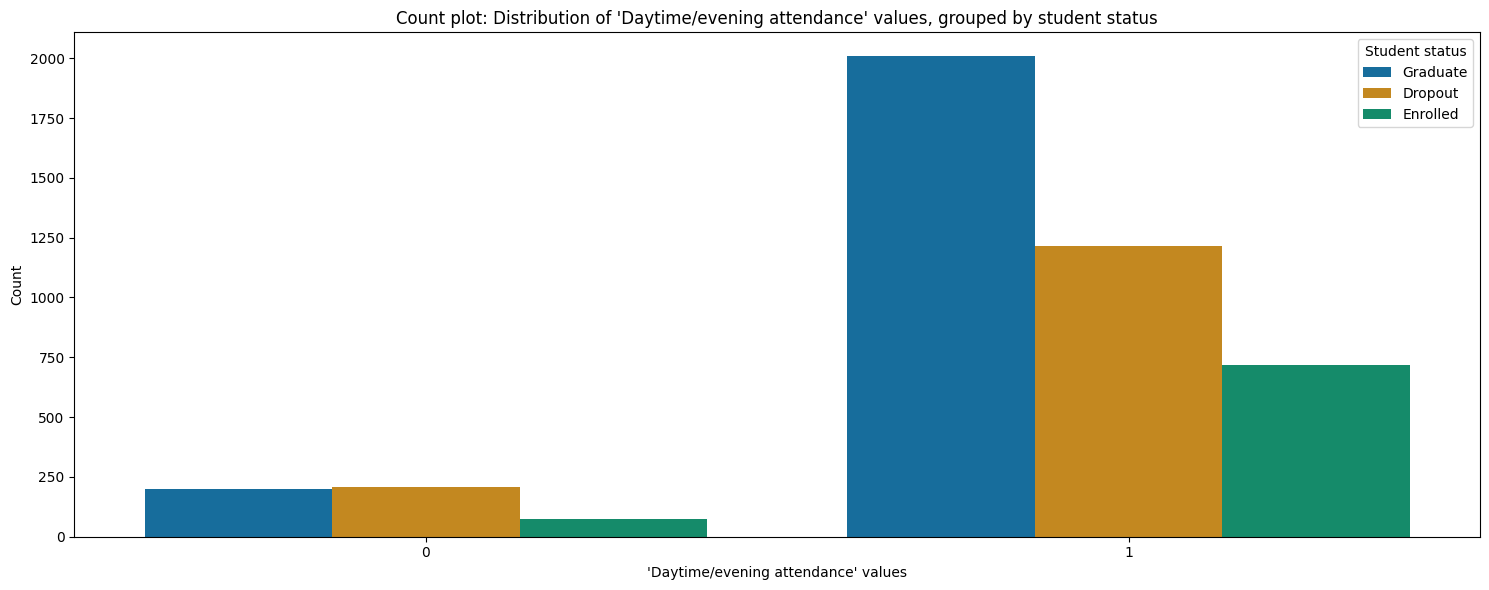

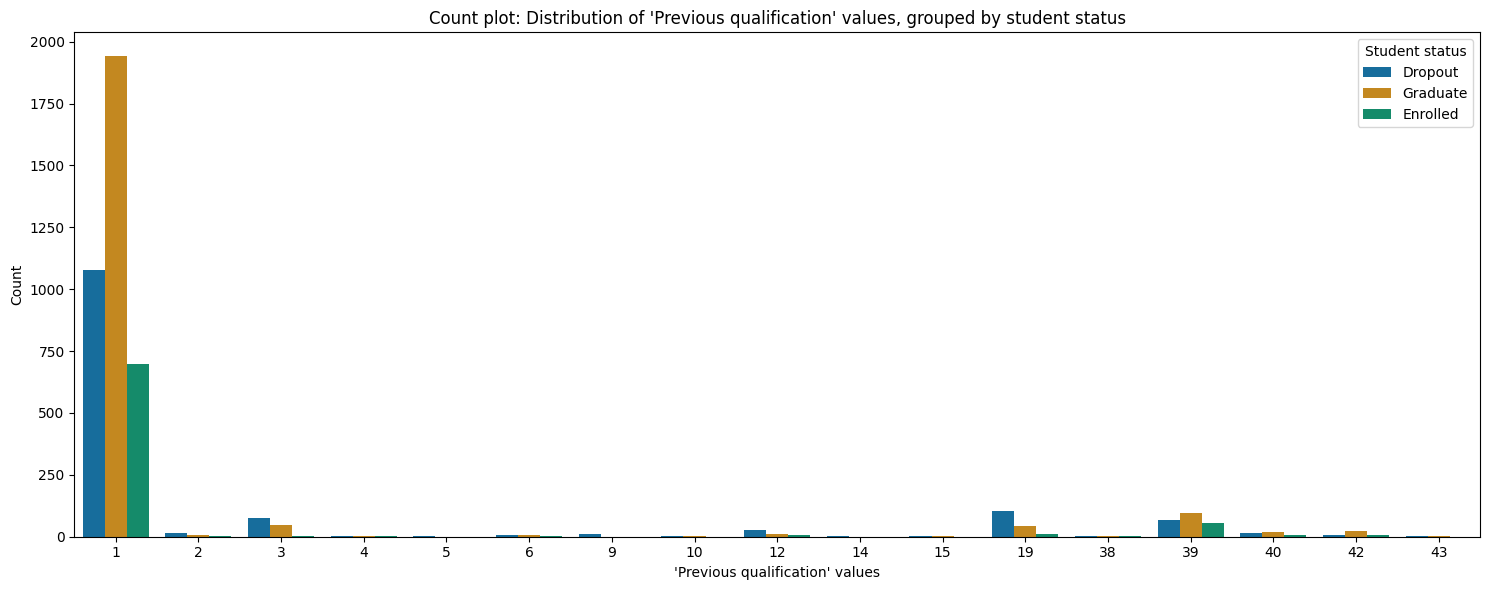

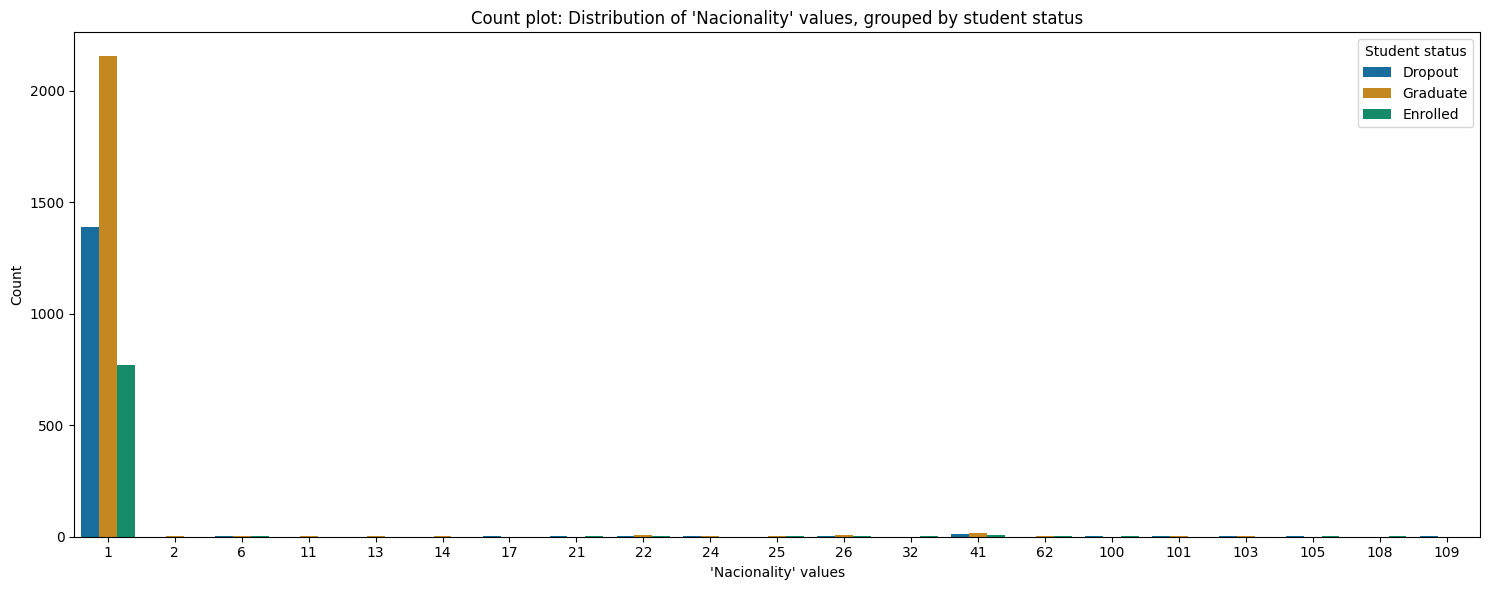

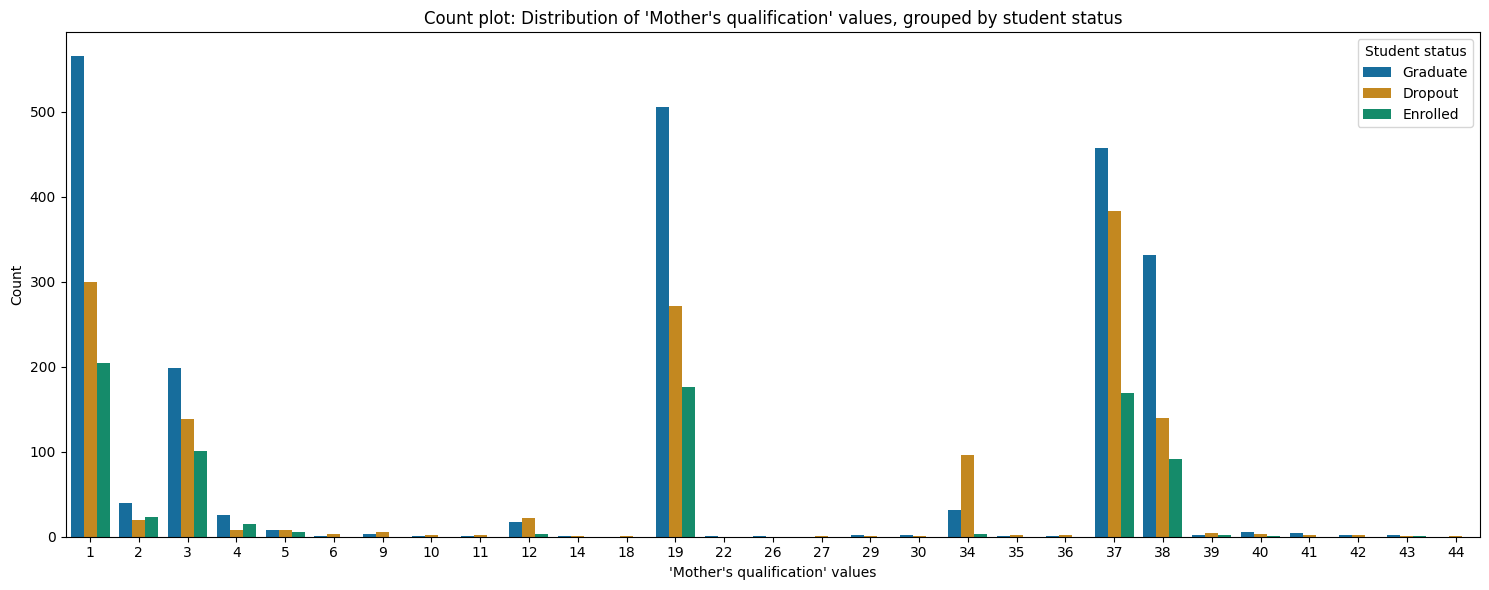

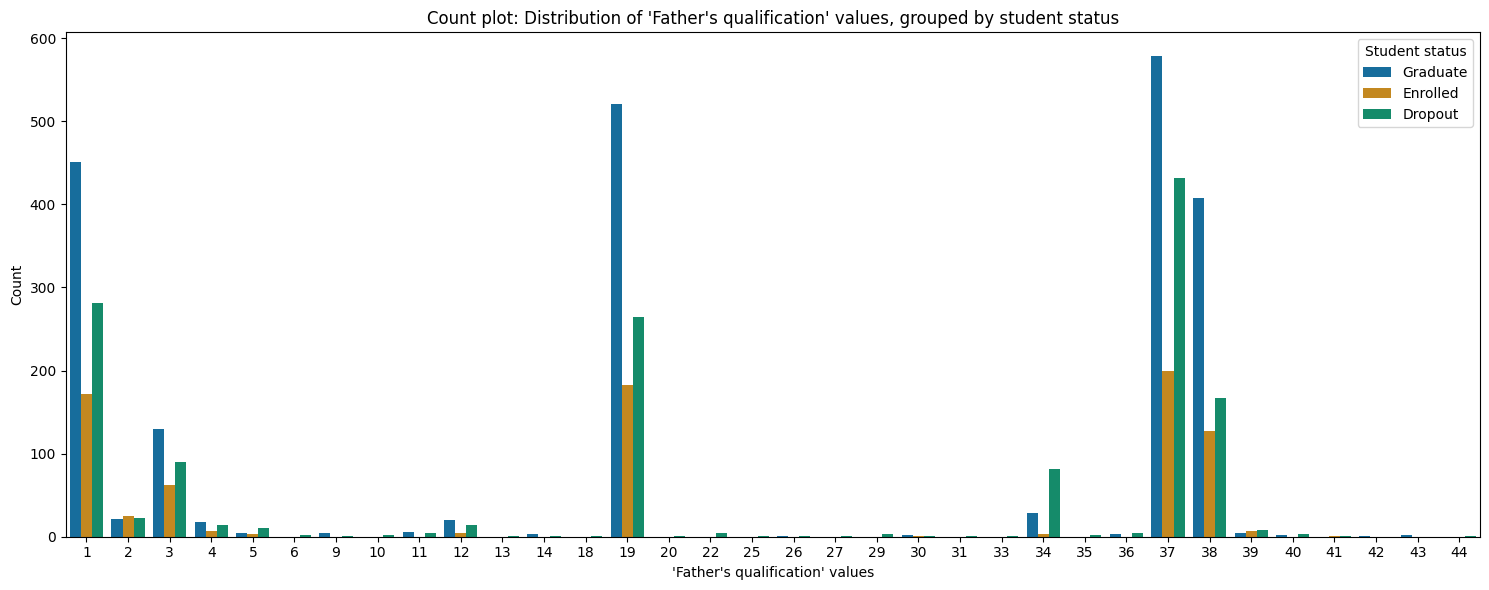

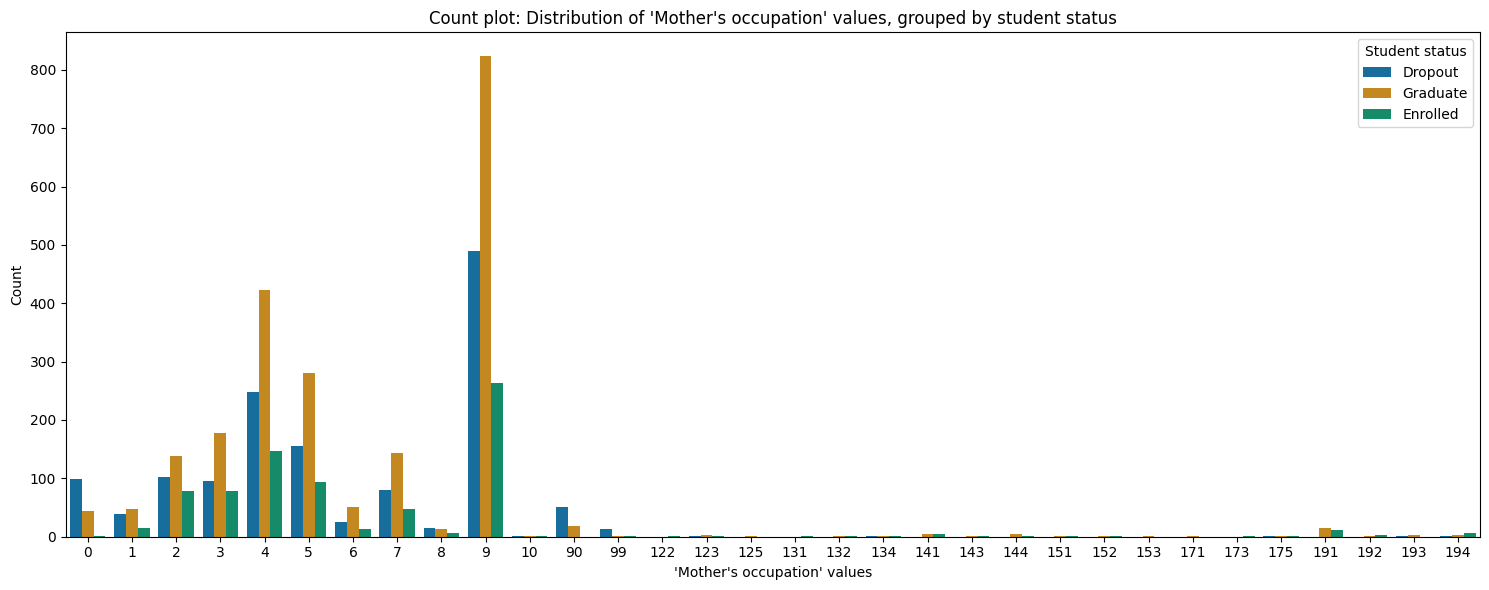

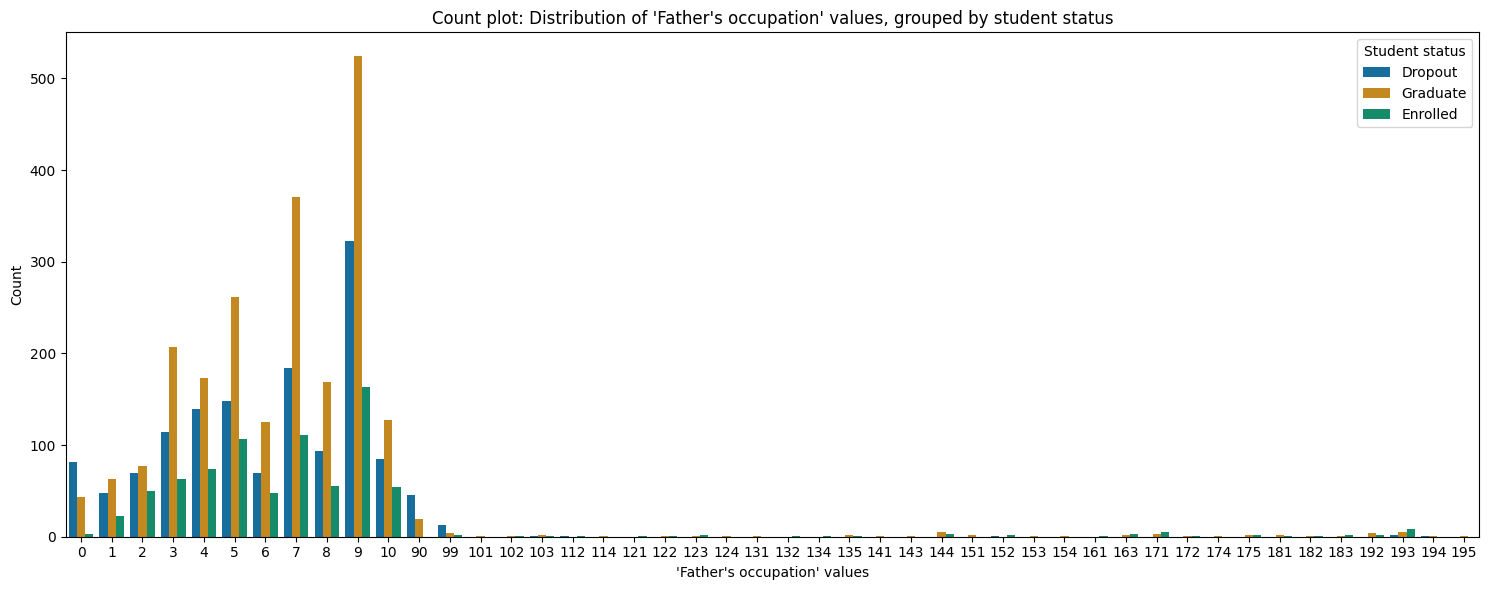

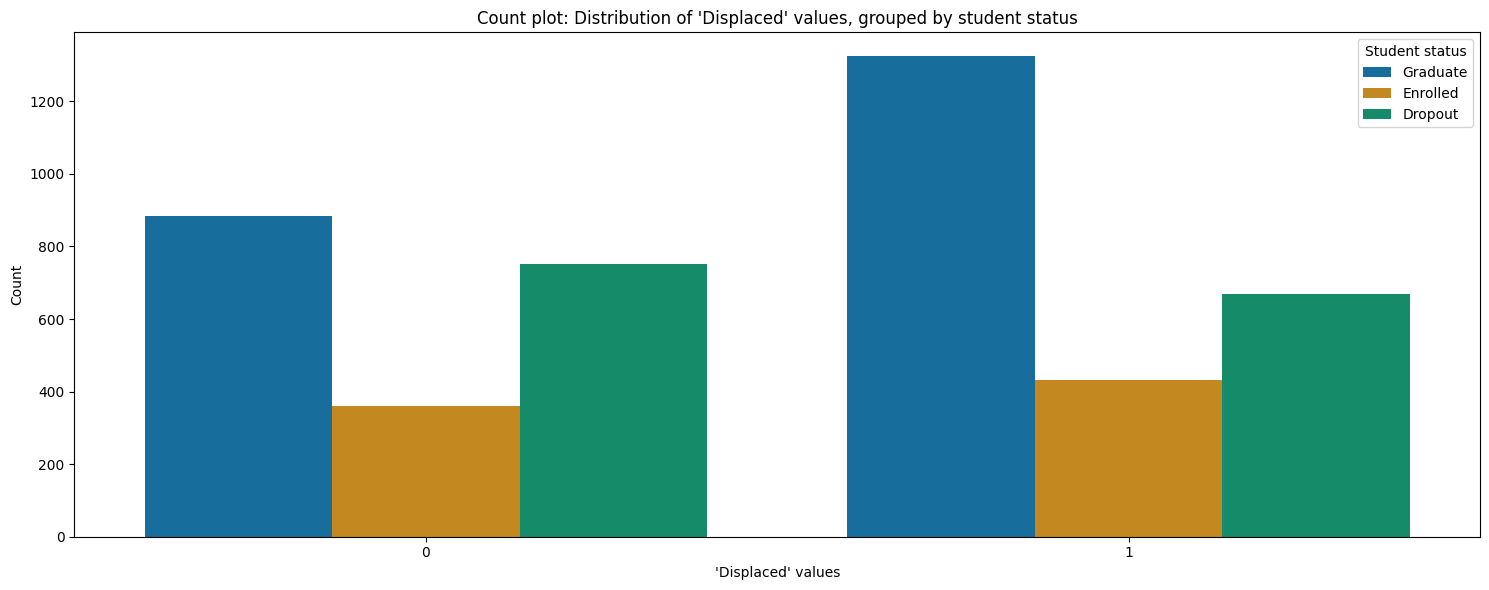

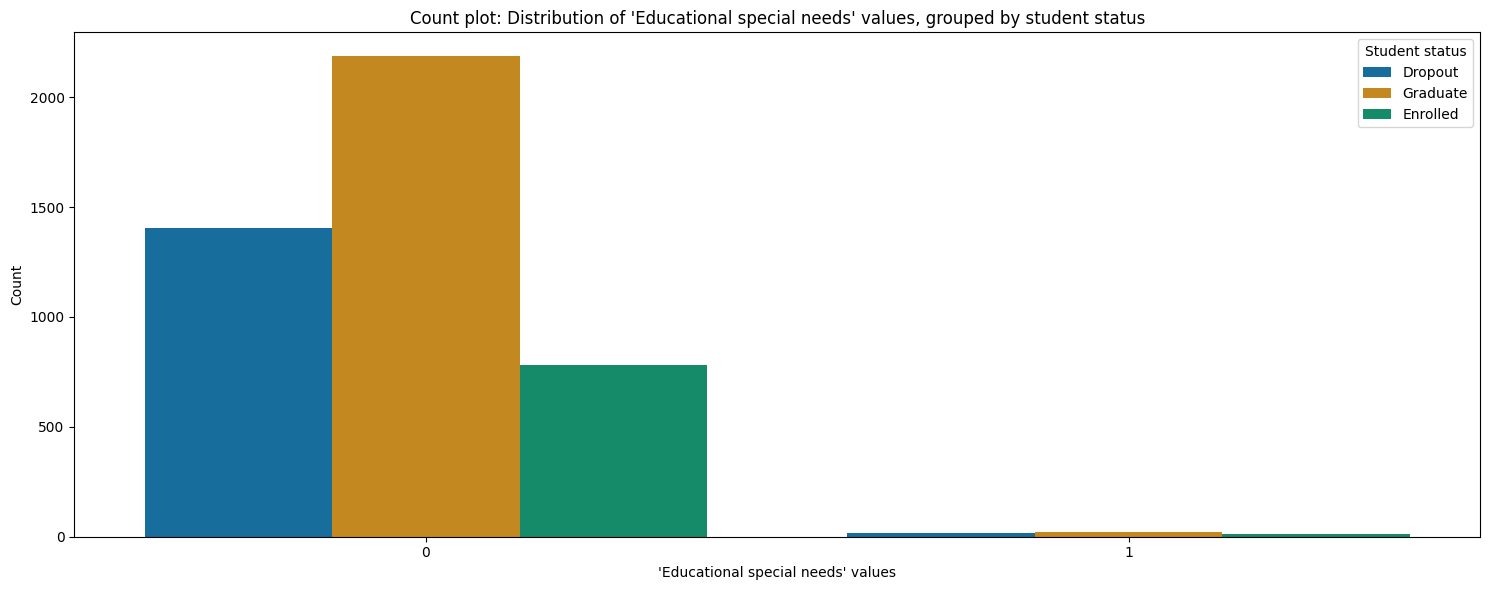

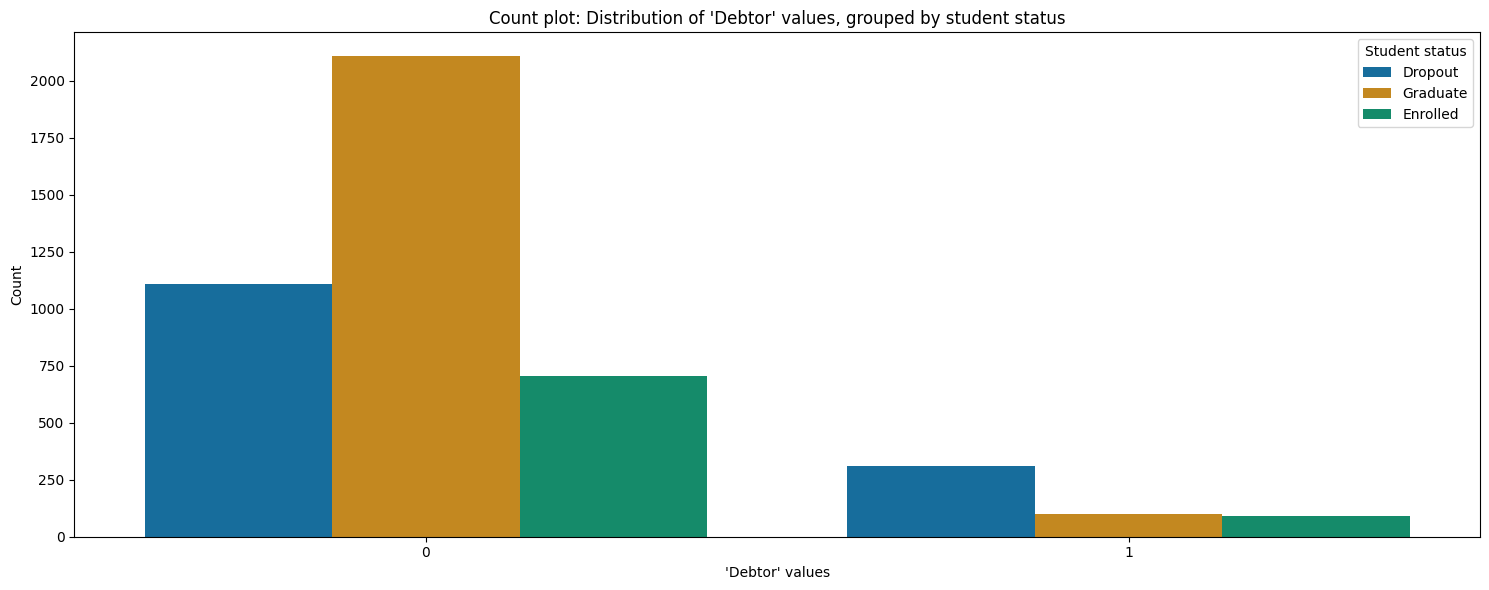

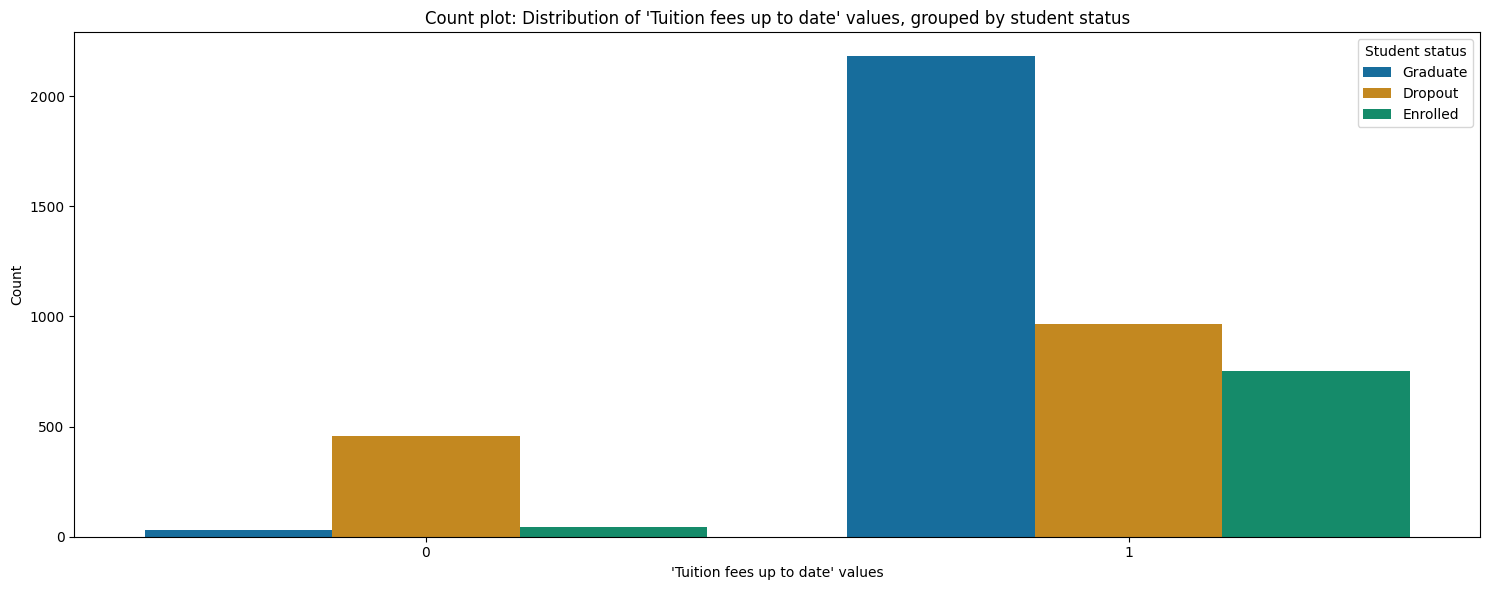

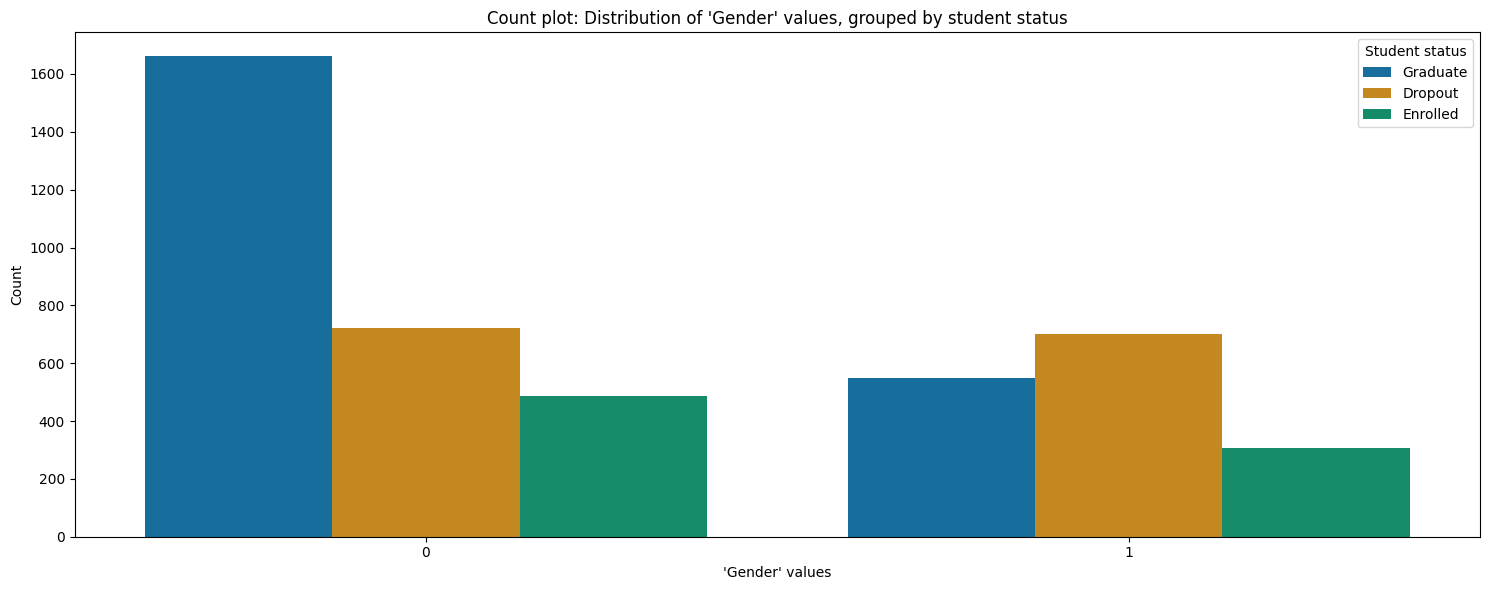

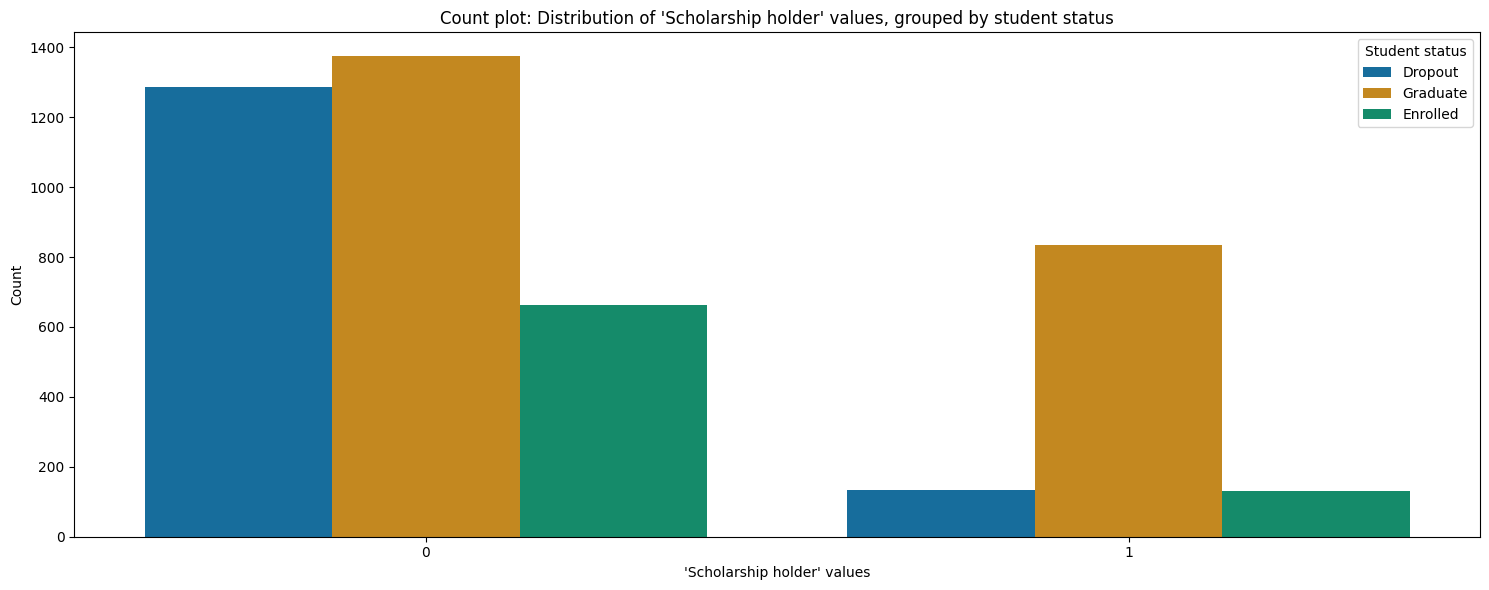

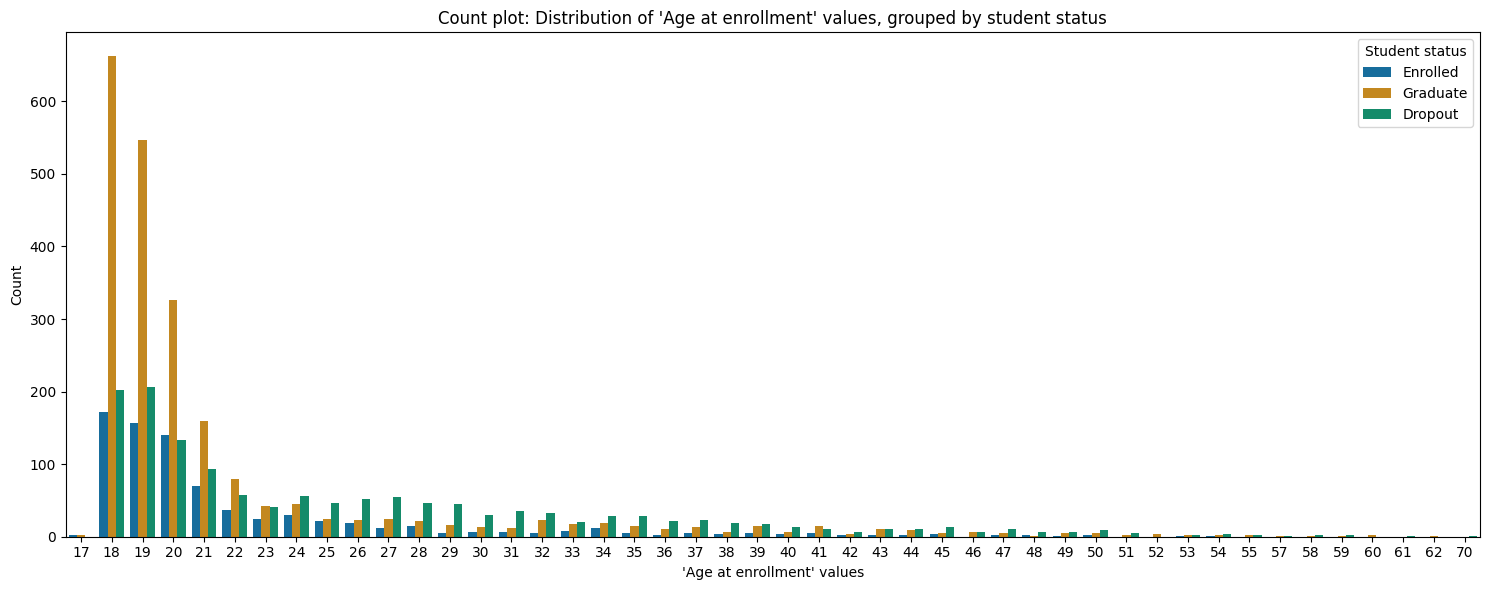

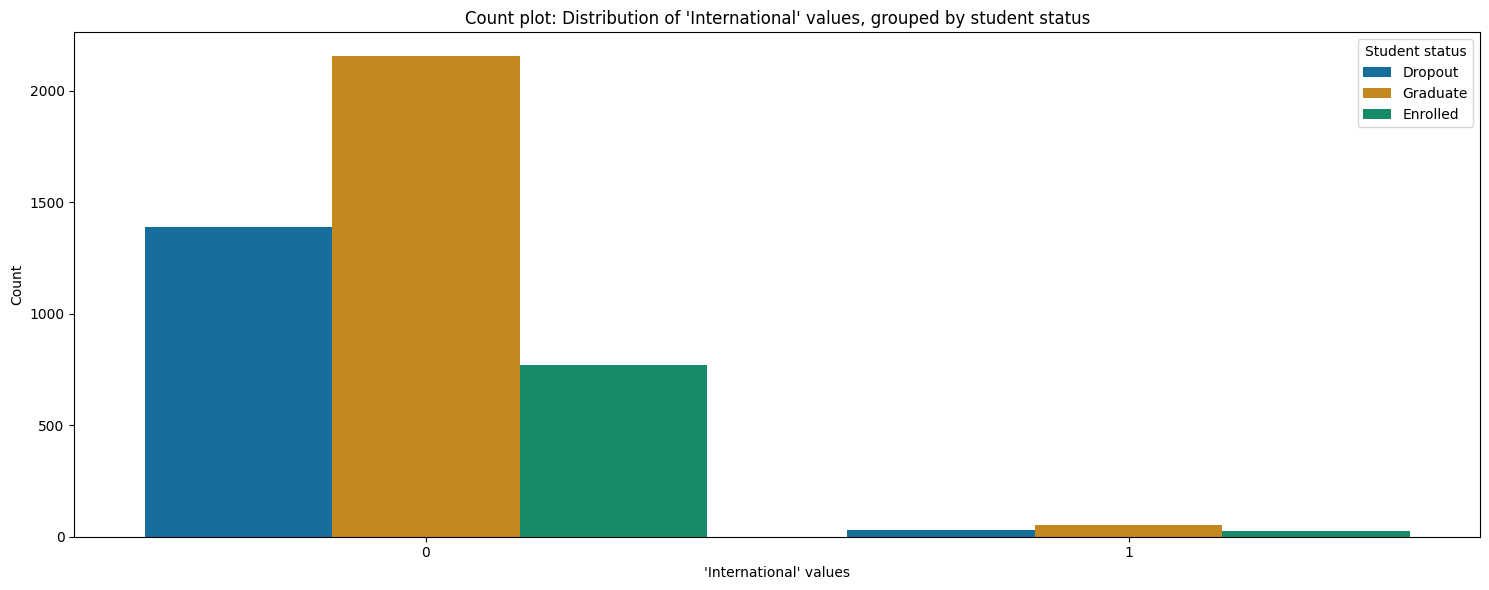

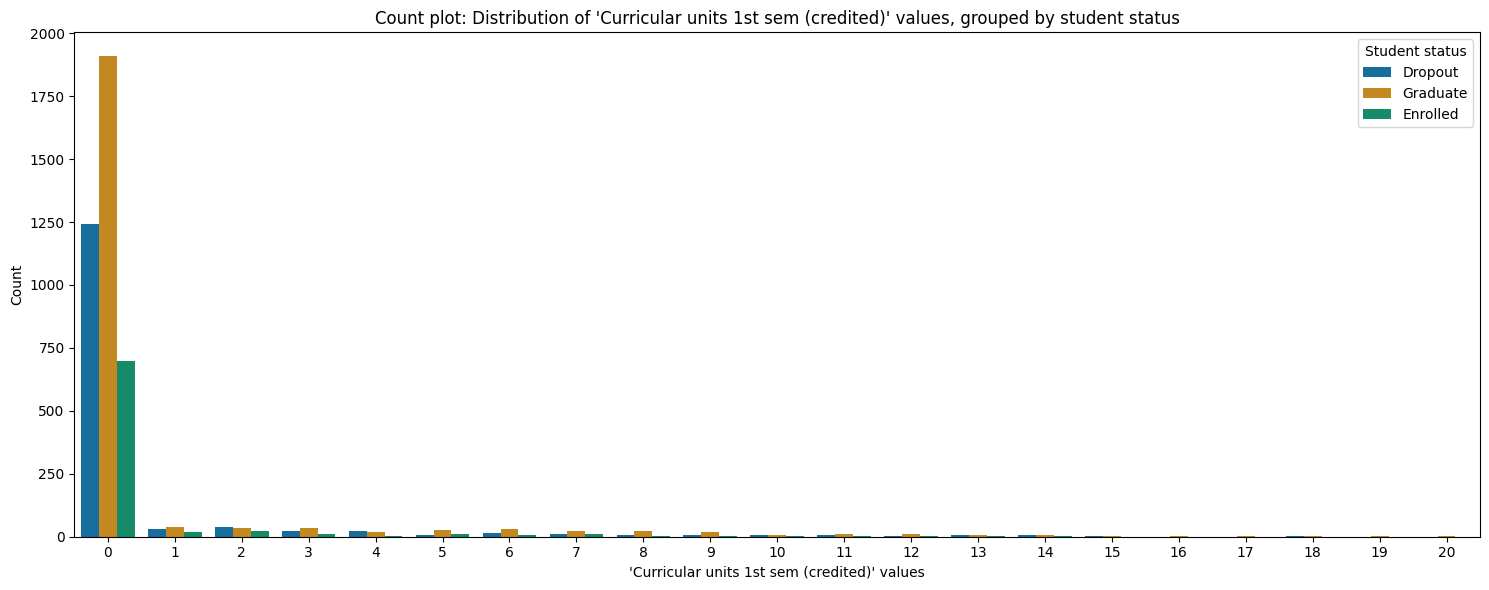

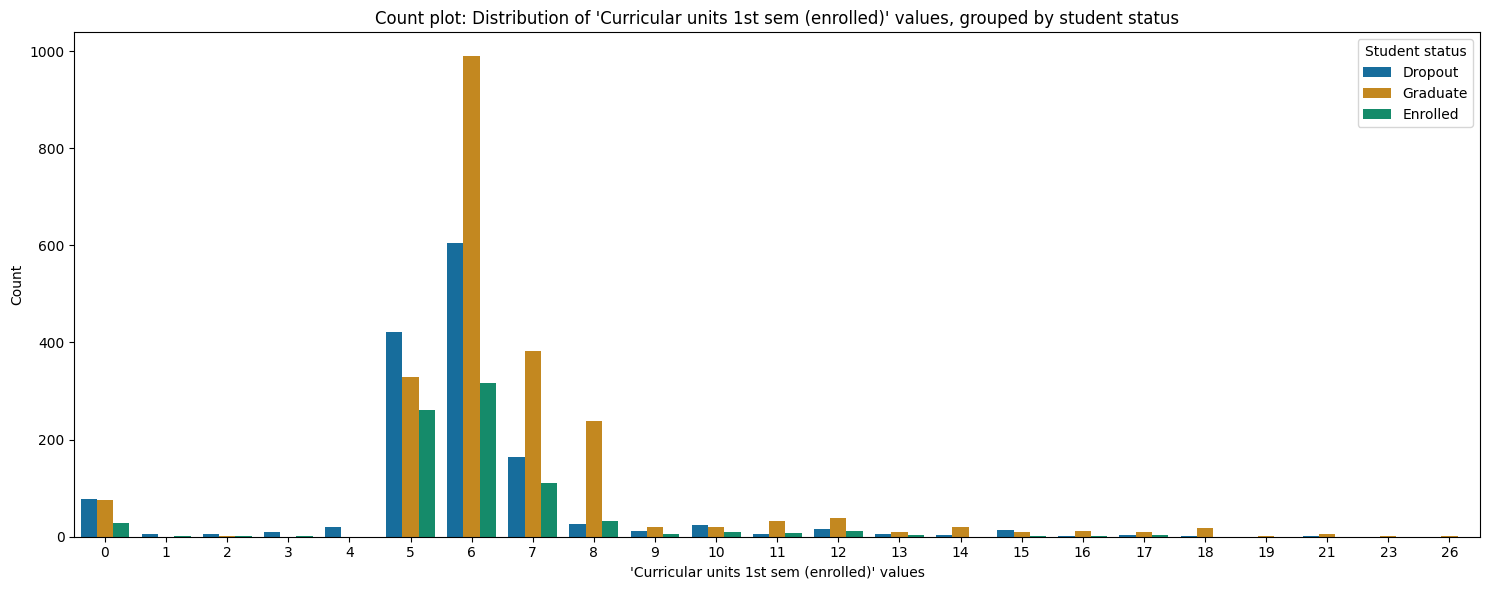

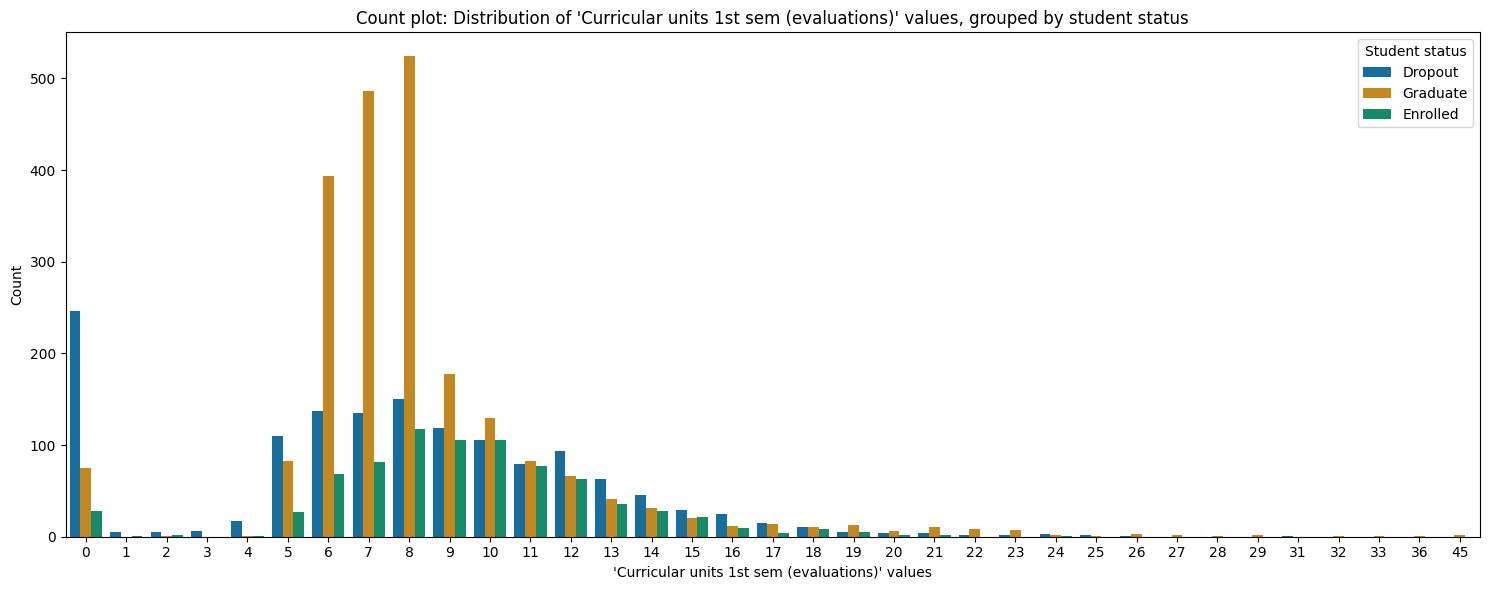

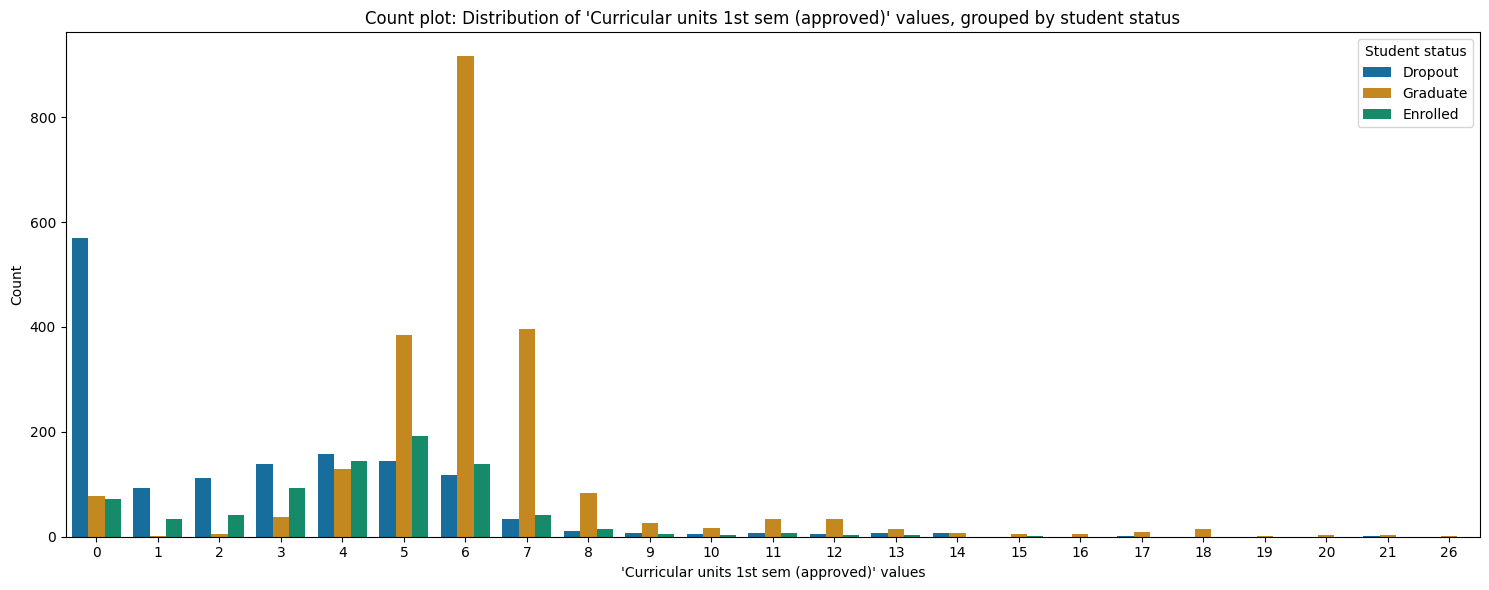

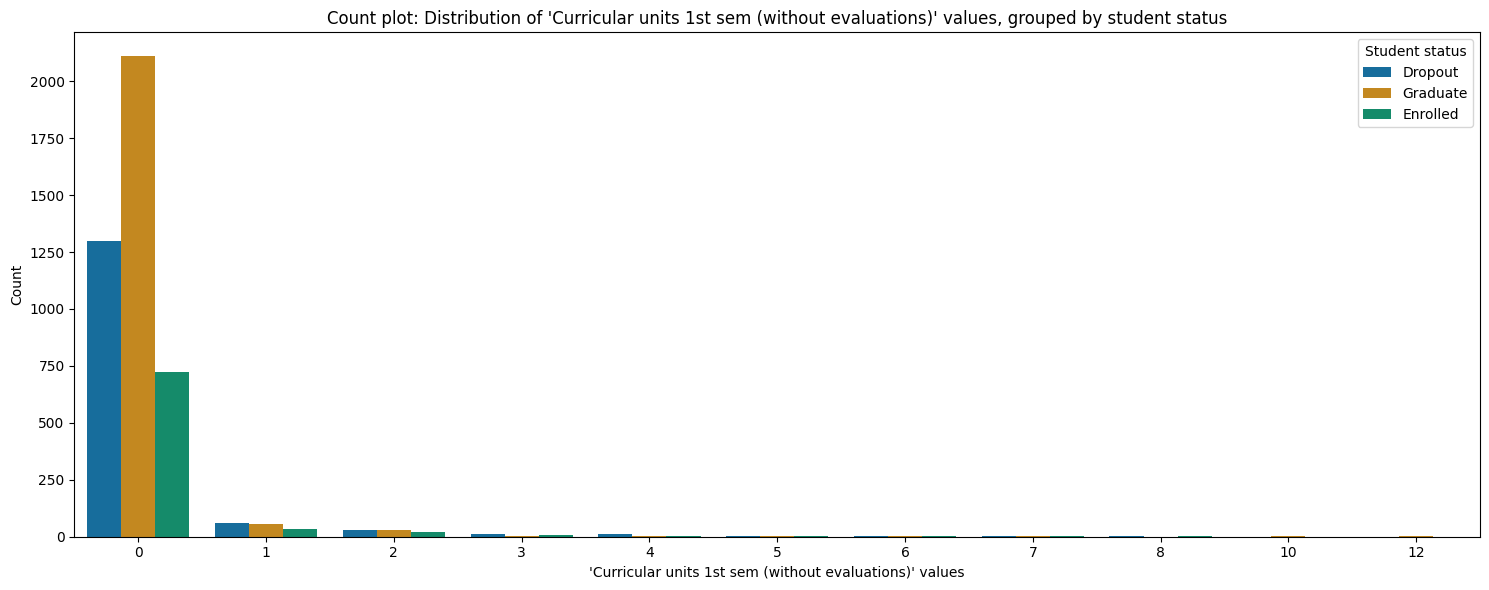

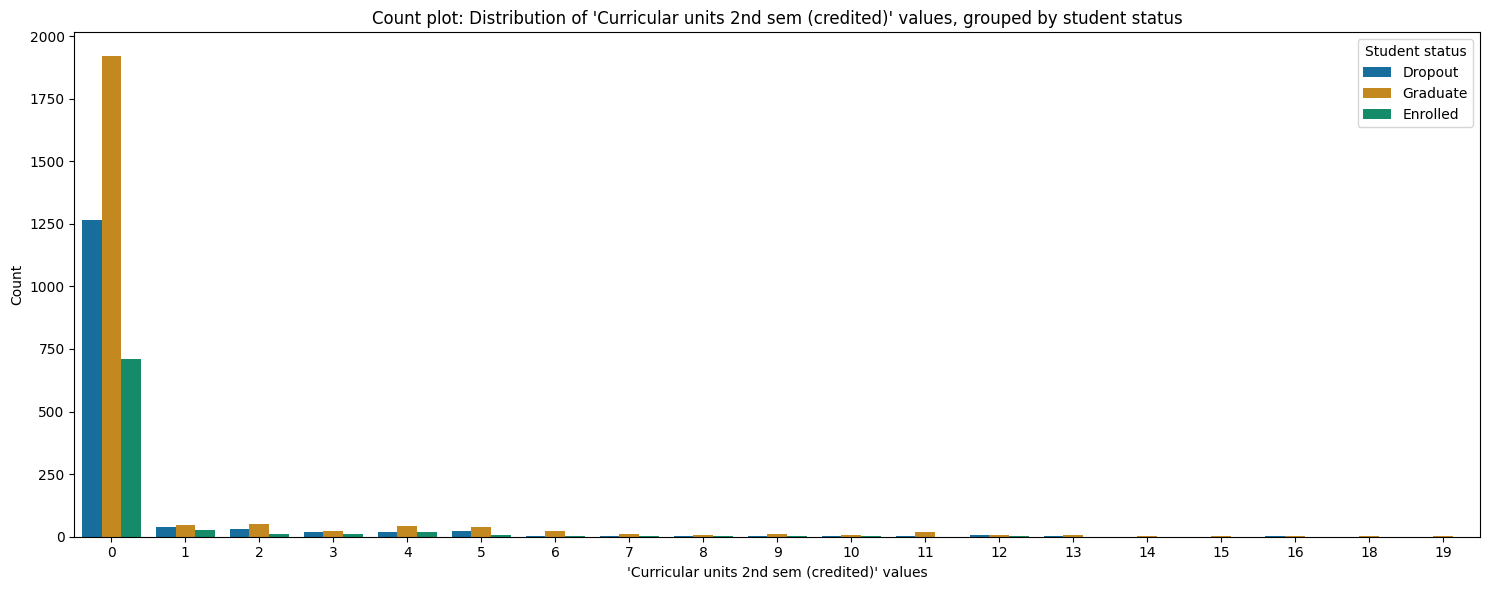

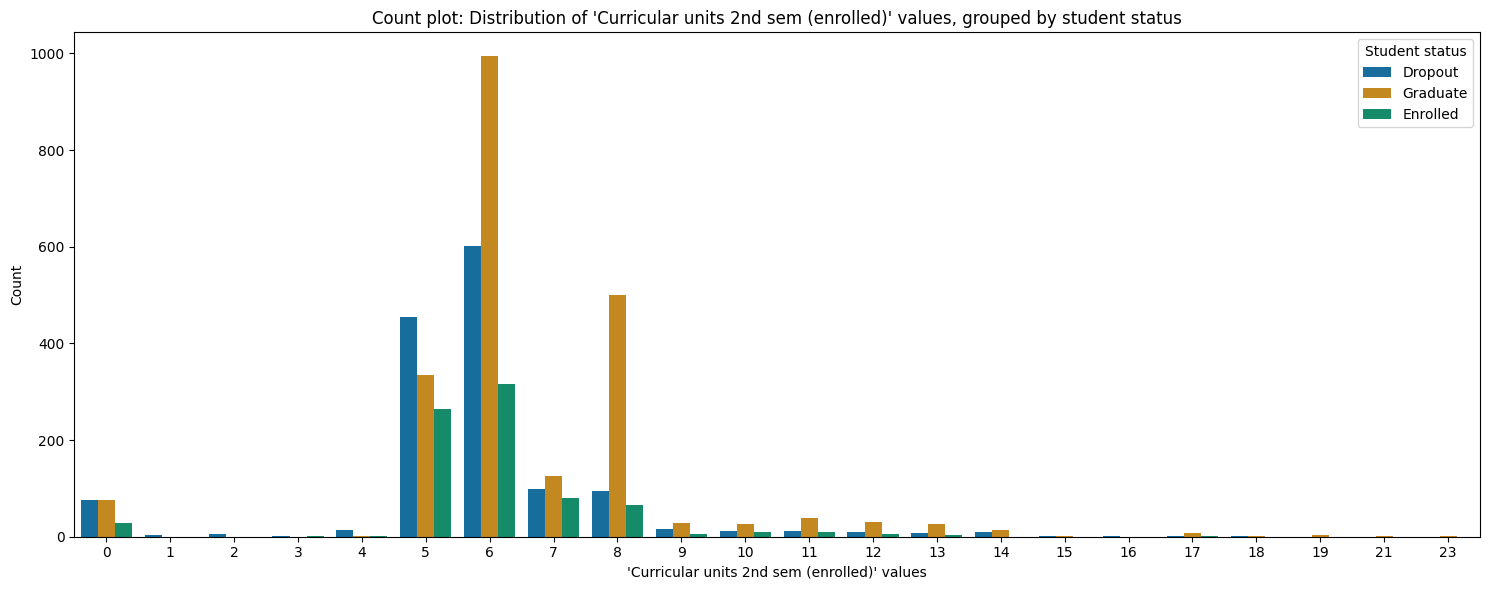

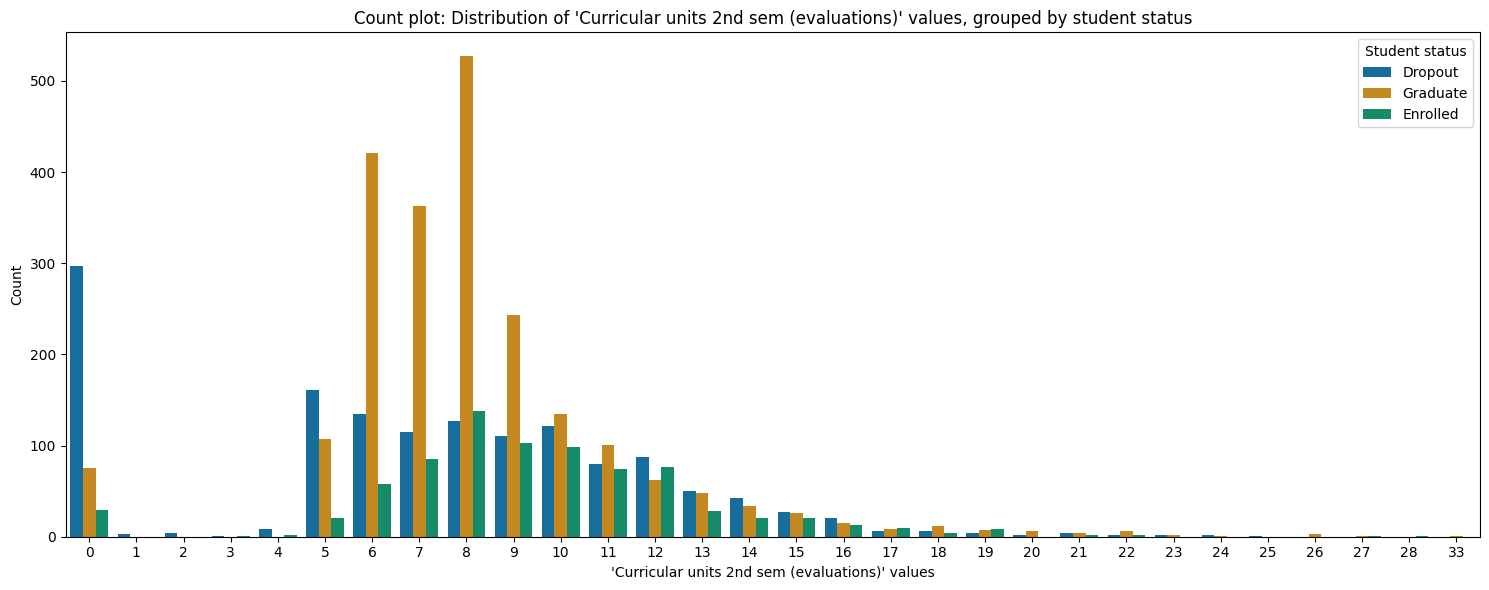

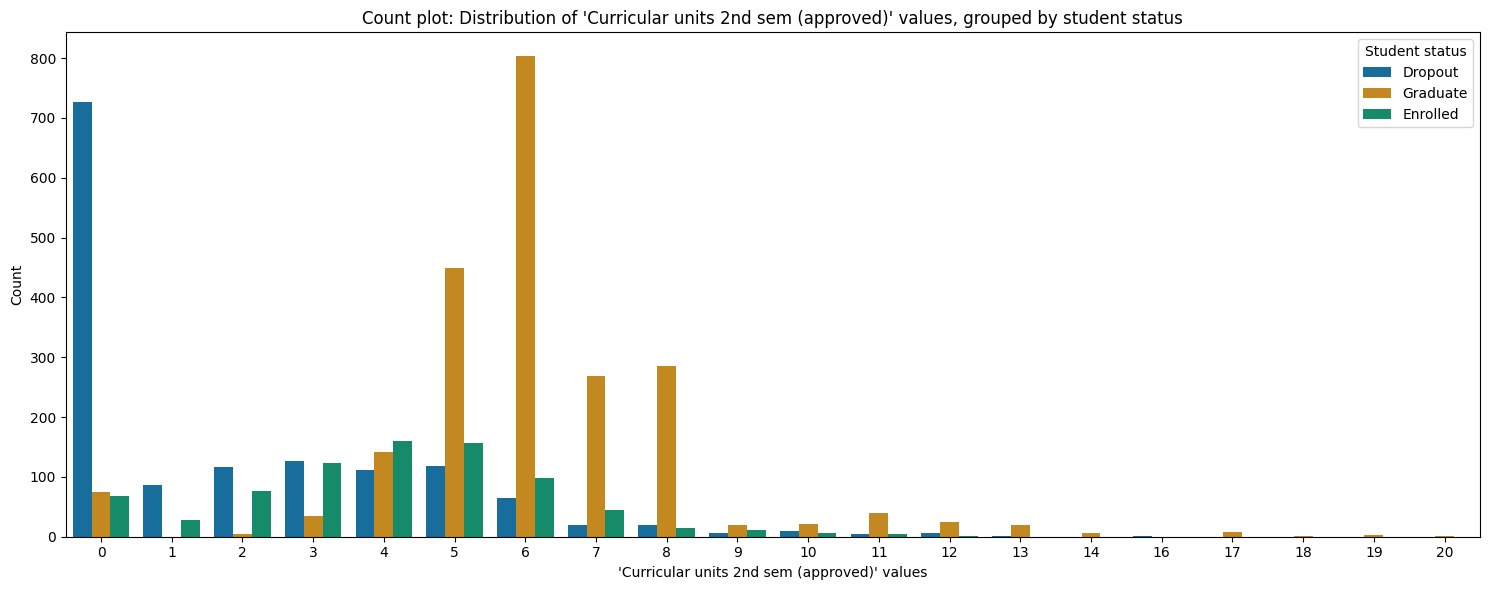

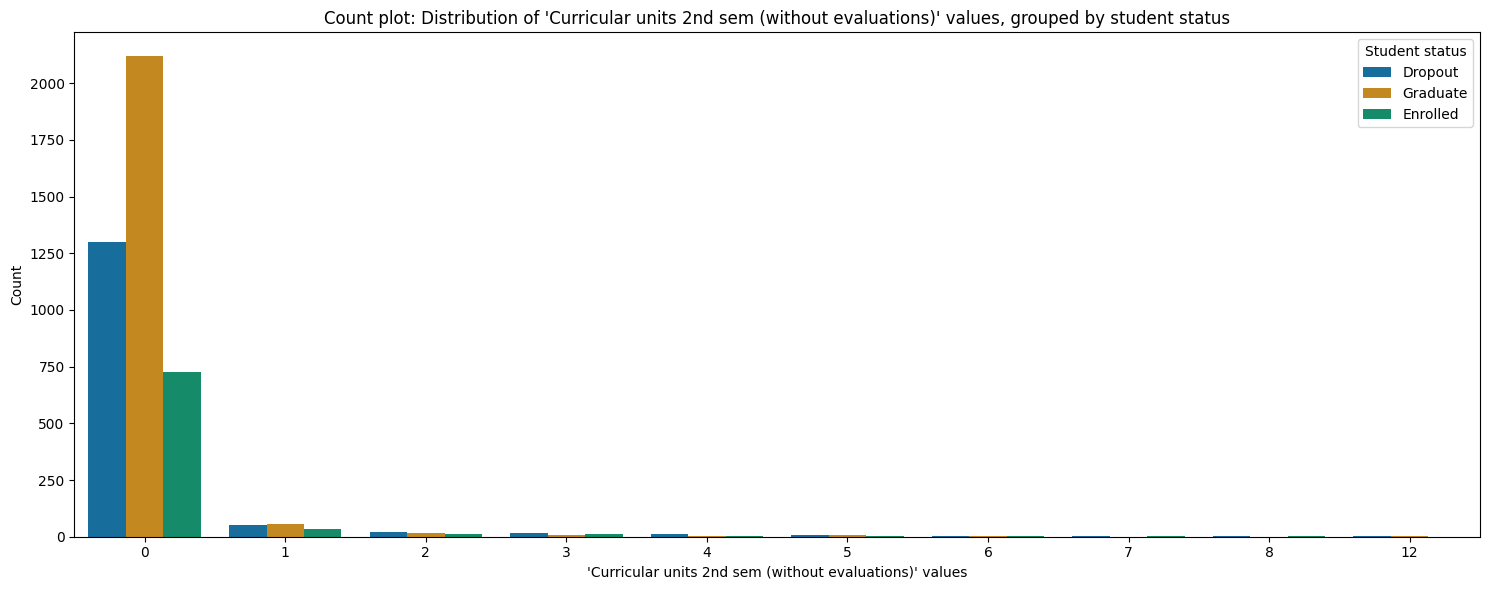

In [16]:
# looping through all categorical columns except the Target column (last one)
for col in list(student_categorical_df.columns[:-1]):
    plt.figure(figsize=(15, 6))

    # count plot distribution of the column values, grouped by target
    sns.countplot(data=student_categorical_df, x=col, hue="Target", palette="colorblind")
    plt.xlabel(f"'{col}' values")
    plt.ylabel("Count")
    plt.title(f"Count plot: Distribution of '{col}' values, grouped by student status")
    plt.legend(title="Student status")
    
    plt.tight_layout()
    plt.show()

## Data Processing

In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder # for transforming the features and target

# isolating the features and target
X = student_continuous_df.drop("Target", axis=1).to_numpy()
y = student_continuous_df["Target"].to_numpy()

# transforming the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# transforming the targets
le = LabelEncoder()
y = le.fit_transform(y).reshape((-1, 1))

print("Features array:")
print(X)
print()
print("Target array:")
print(y)

Features array:
[[-0.80484126  0.02222877 -2.19710239 ... -0.28763846  0.12438647
   0.76576084]
 [ 2.07681932  1.07192614  0.6935986  ...  0.87622207 -1.10522155
   0.34719942]
 [-0.80484126 -0.15041883 -2.19710239 ... -0.28763846  0.12438647
   0.76576084]
 ...
 [ 1.62182028  1.5553394   0.88201036 ...  0.87622207 -1.10522155
   0.34719942]
 [ 3.59348278  1.85229326  0.65230287 ... -0.81325289 -1.46687097
  -1.37551124]
 [ 1.47015393  1.727987    0.2118151  ...  0.42569541  1.7879738
  -0.74987207]]

Target array:
[[0]
 [2]
 [0]
 ...
 [0]
 [2]
 [2]]


In [18]:
# splitting the data
from sklearn.model_selection import train_test_split # for data splitting

# splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=6)

# checking shapes of X
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print()

# checking shapes of y
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")
print()

X_train.shape: (3096, 7)
X_test.shape: (1328, 7)

y_train.shape: (3096, 1)
y_test.shape: (1328, 1)



## SVC without Dimensionality Reduction

In [19]:
# scikit-learn
from sklearn.svm import SVC # for implementation of SVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV # for cross-validation and hyperparameter search
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay # for evaluation of SVM

In [20]:
from scipy.stats import loguniform

# specifying hyperparameter values to search from
param_distributions = {
    'C': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'gamma': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'kernel': ['rbf'],
}

# performing stratified k-fold cross-validation and randomized search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
random_search = RandomizedSearchCV(SVC(random_state=6), param_distributions, n_iter=100, cv=skf, scoring='f1_weighted', n_jobs=-1, random_state=6)

random_search.fit(X_train, y_train.ravel())

print("Training SVC (w/o Dimensionality Reduction) done.")

Training SVC (w/o Dimensionality Reduction) done.


Best Parameters: {'C': np.float64(353.80387872012597), 'gamma': np.float64(0.2695347371288345), 'kernel': 'rbf'}

Classification report:
              precision    recall  f1-score   support

     Dropout       0.67      0.61      0.64       422
    Enrolled       0.29      0.19      0.23       229
    Graduate       0.69      0.82      0.75       677

    accuracy                           0.64      1328
   macro avg       0.55      0.54      0.54      1328
weighted avg       0.62      0.64      0.63      1328



,Dropout,Enrolled,Graduate,accuracy,macro avg,weighted avg
precision,0.673684,0.294521,0.694514,0.644578,0.554239,0.618920
recall,0.606635,0.187773,0.822747,0.644578,0.539052,0.644578
f1-score,0.638404,0.229333,0.753212,0.644578,0.540316,0.626392
support,422.000000,229.000000,677.000000,0.644578,1328.000000,1328.000000


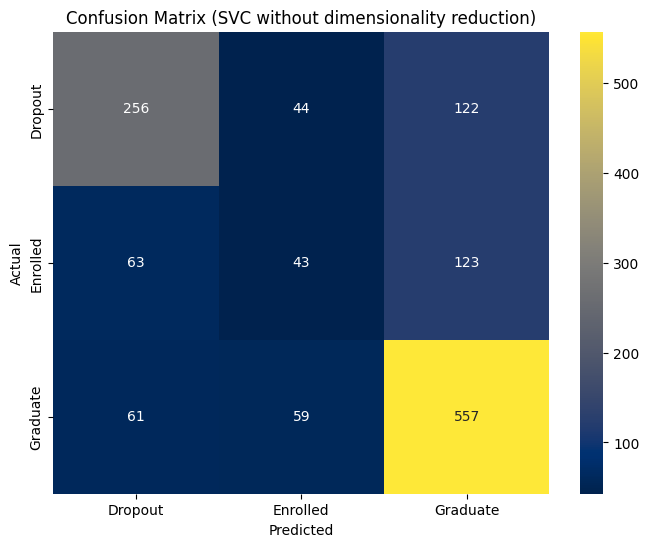

In [21]:
# evaluation

# printing best parameters and predicting using the best estimator
print(f"Best Parameters: {random_search.best_params_}\n")
best_svc = random_search.best_estimator_
y_pred_best = best_svc.predict(X_test)

# evaluating the best classifier
print("Classification report:")
print(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred_best.ravel())))
display(pd.DataFrame(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred_best.ravel()), output_dict=True)))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="cividis", xticklabels=["Dropout", "Enrolled", "Graduate"], yticklabels=["Dropout", "Enrolled", "Graduate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (SVC without dimensionality reduction)")
plt.show()

Best SVC achieved 64% test accuracy using only continuous features.

## SVC with PCA

In [22]:
from sklearn.decomposition import PCA # for implementation of PCA

In [23]:
# performing PCA
pca = PCA(n_components=2) # initializing PCA object with 2 principal components for dimensionality reduction
X_train_pca = pca.fit_transform(X_train, y_train.ravel()) # fit the model with X and apply the dimensionality reduction on X
X_test_pca = pca.transform(X_test) # apply dimensionality reduction to X; X is projected on the first principal components previously extracted from a training set

In [24]:
# re-specifying hyperparameter values to search from
param_distributions = {
    'C': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'gamma': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'kernel': ['rbf'],
}

# performing stratified k-fold cross-validation and randomized search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
random_search = RandomizedSearchCV(SVC(random_state=6), param_distributions, n_iter=100, cv=skf, scoring='f1_weighted', n_jobs=-1, random_state=6)

random_search.fit(X_train_pca, y_train.ravel())

print("Training SVC (w/ PCA) done.")

Training SVC (w/ PCA) done.


Best Parameters: {'C': np.float64(2.331582532987705), 'gamma': np.float64(10.205314874336242), 'kernel': 'rbf'}

Classification report:
              precision    recall  f1-score   support

     Dropout       0.76      0.55      0.64       422
    Enrolled       0.19      0.06      0.09       229
    Graduate       0.65      0.91      0.76       677

    accuracy                           0.65      1328
   macro avg       0.53      0.51      0.50      1328
weighted avg       0.60      0.65      0.61      1328



,Dropout,Enrolled,Graduate,accuracy,macro avg,weighted avg
precision,0.759740,0.188406,0.648791,0.650602,0.532312,0.604659
recall,0.554502,0.056769,0.911374,0.650602,0.507548,0.650602
f1-score,0.641096,0.087248,0.757985,0.650602,0.495443,0.605179
support,422.000000,229.000000,677.000000,0.650602,1328.000000,1328.000000


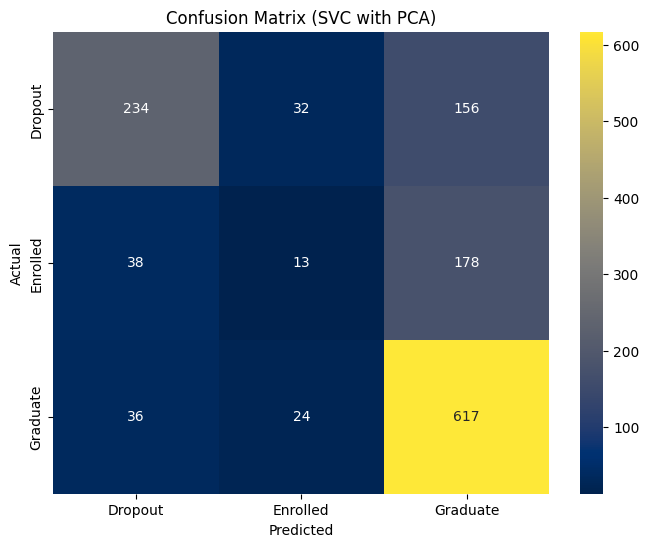

In [25]:
# evaluation

# printing best parameters and predicting using the best estimator
print(f"Best Parameters: {random_search.best_params_}\n")
best_svc = random_search.best_estimator_
y_pred_best = best_svc.predict(X_test_pca)

# evaluating the best classifier
print("Classification report:")
print(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred_best.ravel())))
display(pd.DataFrame(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred_best.ravel()), output_dict=True)))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="cividis", xticklabels=["Dropout", "Enrolled", "Graduate"], yticklabels=["Dropout", "Enrolled", "Graduate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (SVC with PCA)")
plt.show()

Best SVC (with PCA) achieved 65% test accuracy using only continuous features.

## LDA

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # for implementation of LDA

Classification report:
              precision    recall  f1-score   support

     Dropout       0.86      0.52      0.65       422
    Enrolled       0.00      0.00      0.00       229
    Graduate       0.61      0.97      0.75       677

    accuracy                           0.66      1328
   macro avg       0.49      0.50      0.47      1328
weighted avg       0.58      0.66      0.59      1328



c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: Unde

,Dropout,Enrolled,Graduate,accuracy,macro avg,weighted avg
precision,0.858824,0.0,0.611370,0.658886,0.490065,0.584579
recall,0.518957,0.0,0.968981,0.658886,0.495979,0.658886
f1-score,0.646972,0.0,0.749714,0.658886,0.465562,0.587785
support,422.000000,229.0,677.000000,0.658886,1328.000000,1328.000000


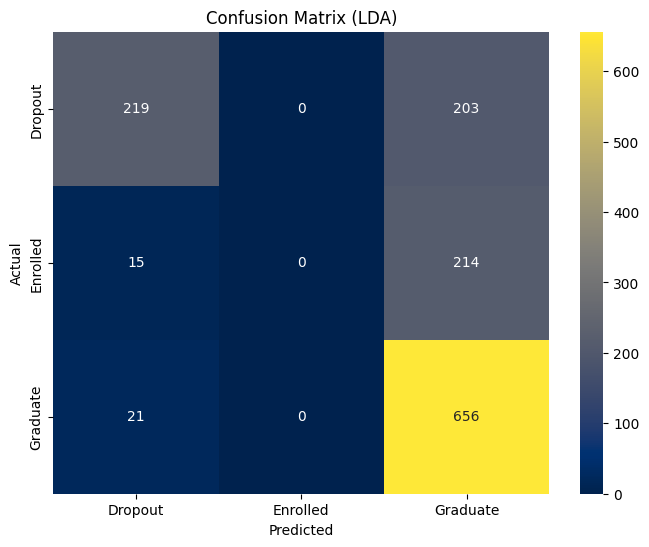

In [31]:
# performing LDA
lda = LinearDiscriminantAnalysis(n_components=2) # initializing LDA object
lda.fit(X_train, y_train.ravel())
y_pred = lda.predict(X_test)

# evaluating LDA
print("Classification report:")
print(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred.ravel())))
display(pd.DataFrame(classification_report(le.inverse_transform(y_test.ravel()), le.inverse_transform(y_pred.ravel()), output_dict=True)))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="cividis", xticklabels=["Dropout", "Enrolled", "Graduate"], yticklabels=["Dropout", "Enrolled", "Graduate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (LDA)")
plt.show()

LDA achieved 66% test accuracy using only continuous features. 

## Summary

* Student status classification has been done using the dataset.
* In particular, dimensionality reduction is employed.
* From the experiments, it showed that accuracy increased when dimensionality reduction is employed (from 64% using SVC alone, to 65% using SVC and PCA, to 66% using LDA). However, the results are not that conclusive since accuracy score only increased marginally. It is thought that further data processing or feature selection is needed since the dataset is complex, having numerous features with differing data types.